# Auditory Superstitious Perception Data Analysis

Thi code computes many things (Don't foget to add these)

- All the things


Three reporting groups everywhere: UChicago alone, Oberlin alone, and a unified pool.

## 1.  Imports, constants, and output directories

In [38]:
# ============================================================================
# Packages we import to run computations
# ============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import warnings
from scipy.stats import (wilcoxon, mannwhitneyu, spearmanr, ttest_1samp,
                        ttest_ind, ttest_rel, norm)
from sklearn.linear_model import LogisticRegression


# ============================================================================
# Where data + important things live so we can reference them later
# ============================================================================

# The folder with this file + all of our data
CURRENT_DIRECTORY = Path.cwd().resolve()

# The folder containing the raw subject data
RAW_DATA_PATH    = CURRENT_DIRECTORY / "raw_data"

# The folder with the audio stimuli used in the experiment 
AUDIO_STIM_PATH  = RAW_DATA_PATH / "audio_stimuli"

# Where we save all of the images that we create
FIGURES_PATH     = CURRENT_DIRECTORY / "figures"

# Where we save all the CSVs we create
TABLES_PATH      = CURRENT_DIRECTORY / "tables"

# Create the folders for the images and the CSVs if they don't exist already
FIGURES_PATH.mkdir(parents = True, exist_ok = True)
TABLES_PATH .mkdir(parents = True, exist_ok = True)


# ============================================================================
# Constants used throughout.
# ============================================================================

# How we will refer to all of the different questionnaires
QUESTIONNAIRE_COLUMNS = ["BAIS_V", "BAIS_C", "VHQ", "TAS", "LSHS", "DES",
                         "FSS", "SSS_mean"]

# Some nice colors for the different graphs (uchicago, oberlin, unified)
SITE_COLOR  = {"UChicago": "#9467bd",
               "Oberlin":  "#2ca02c",
               "Unified":  "#1f77b4"}

# A dictionary to let us translate between how the blocks were written
#   in the code and how we want to see them on the graphs
BLOCK_LABEL = {"full_sentence":     "Full Sentence",
               "imagined_sentence": "Imagined Sentence"}

# One seeded RNG for every bootstrap / permutation / sub-sample
RNG = np.random.default_rng(20260501)

# Print all of these paths in case the code complains it cannot
#   find something... this is an easy way to check what is wrong
print(f"CURRENT_DIRECTORY = {CURRENT_DIRECTORY}")
print(f"RAW_DATA_PATH     = {RAW_DATA_PATH}")
print(f"AUDIO_STIM_PATH   = {AUDIO_STIM_PATH}")
print(f"FIGURES_PATH      = {FIGURES_PATH}")
print(f"TABLES_PATH       = {TABLES_PATH}")


CURRENT_DIRECTORY = /home/david/Desktop/Projects/auditory-sp-analyses/jupyter_notebook
RAW_DATA_PATH     = /home/david/Desktop/Projects/auditory-sp-analyses/jupyter_notebook/raw_data
AUDIO_STIM_PATH   = /home/david/Desktop/Projects/auditory-sp-analyses/jupyter_notebook/raw_data/audio_stimuli
FIGURES_PATH      = /home/david/Desktop/Projects/auditory-sp-analyses/jupyter_notebook/figures
TABLES_PATH       = /home/david/Desktop/Projects/auditory-sp-analyses/jupyter_notebook/tables


## 2.  Load every per-trial CSV into one long table

`raw_data/<site>/<subject_number>/<block_type>/<block_type>_<subject_number>.csv` has
one row per trial with columns including `Stimulus Number`,
`Stimulus Type` (the experimenter label), and `Subject Response` (what
the subject called it).  Collected here into one `trial_table`.

In [39]:
# ============================================================================
# A function to load all of the trials. 
# The output is a list where each entry is a single trial
# ============================================================================

def load_trial_table():
    
    # Predefine a list for storing all of the rows
    rows = [] 

    # Iterate over our two experimental sites
    for site in ("Oberlin", "UChicago"):

        # Define the location of each experimental site's data
        site_root = RAW_DATA_PATH / site

        # If it does not exist then throw an error
        if not site_root.exists():
            print("no folder found")

        # Iterate over each subject's data 
        #   (a folder within the experimental site folder) 
        for subject_dir in sorted(p for p in site_root.iterdir() if p.is_dir()):

            # Get the subject id from the folder name
            subject_id = str(subject_dir.name)

            # Iterate over both of the blocks that the subject performed 
            #   (Full Sentence and Imagined Sentence)
            for block_type in ("full_sentence", "imagined_sentence"):
                
                # Path to the csv with the trial data for the given block
                trial_csv = (subject_dir / block_type / f"{block_type}_{subject_id}.csv")

                # Print any missing trial csvs
                if not trial_csv.exists():
                    print("Missing Trial CSV")
                    print(trial_csv)
                    print(subject_id)
                
                # Load the subject's data for this block into a pandas dataframe
                trial_df = pd.read_csv(trial_csv)

                # Iterate over each of the trials in subject's data 
                #   and add to the overall list of rows of trial data
                for trial_index, row in enumerate(trial_df.itertuples(index = False)):
                    rows.append(dict(
                        site             = site,             # Oberlin vs UChicago
                        subject          = subject_id,       # Subject ID
                        block_type       = block_type,       # Full Sentence vs Imagined Sentence
                        trial_index      = trial_index,      # How late in the block this was
                        stimulus_number  = str(int(row[2])), # Stimulus Number
                        stimulus_type    = str(row[3]),      # Stimulus Type
                        subject_response = str(row[4])))      # Subject Response
    
    # Give more formal dataframe structure for saving to csv
    table = pd.DataFrame(rows)

    # Set to true if this is a target (by our experimenter definition)
    #   (Cast to int means that "True" is saved as "1" and "False" as "0"
    table["is_target_true"] = (table["stimulus_type"] == "target").astype(int)

    # Same idea but this represents whether the subject called it a target or a distractor
    table["called_target"]  = (table["subject_response"] == "target").astype(int)

    # Stores whether the subject was correct on the trial
    table["correct"] = ((table["stimulus_type"] == table["subject_response"]).astype(int))
    
    # Return the full, nicely formatted list of trials
    return table

# Invoke the function above and store the full list of trials
trial_table = load_trial_table()

# Print some helpful info about the trials
print(f"Loaded {len(trial_table)} trials\n"
      f"{trial_table['subject'].nunique()} subjects\n"
      f"sites = {dict(trial_table.groupby('site')['subject'].nunique())}")
trial_table.head()


Loaded 7748 trials
26 subjects
sites = {'Oberlin': np.int64(16), 'UChicago': np.int64(10)}


,site,subject,block_type,trial_index,stimulus_number,stimulus_type,subject_response,is_target_true,called_target,correct
0,Oberlin,02242025001,full_sentence,0,80741,target,target,1,1,1
1,Oberlin,02242025001,full_sentence,1,930786,distractor,distractor,0,0,1
2,Oberlin,02242025001,full_sentence,2,2645024,distractor,target,0,1,0
3,Oberlin,02242025001,full_sentence,3,847501,distractor,target,0,1,0
4,Oberlin,02242025001,full_sentence,4,1974580,distractor,target,0,1,0


## 3.  Per-subject accuracy and $d'$ from trials

For each (subject, block_type):

- `accuracy` = $P(\text{response} = \text{stimulus\_type})$
- `hit_rate` = $P(\text{call target} \mid \text{true target})$
- `false_alarm_rate` = $P(\text{call target} \mid \text{true distractor})$
- $d' = \Phi^{-1}(\text{hit\_rate}) - \Phi^{-1}(\text{false\_alarm\_rate})$,
  with the conventional $1/(2N)$ correction at the boundaries.

In [40]:
# ============================================================================
# Per-subject accuracy + d' from raw trials.
# ============================================================================

# Just makes sure we dont get errors/infinite values for the inverse CDF
#   So it does some error checking but all it really does is return the inverse 
#   CDF value
def _safe_norm_inv(rate, n_trials):
    if rate <= 0:
        rate = 1.0 / (2.0 * n_trials)
    elif rate >= 1:
        rate = 1.0 - 1.0 / (2.0 * n_trials)
    return float(norm.ppf(rate))


def compute_accuracy_and_dprime(trial_table):

    # Group by each of the relevant values
    #   We group by site + subject number since subject numbers are only necessarily
    #       unique within given experimental sites.
    #   We further group by block type since each subject has two blocks.
    # We do this because want to get each subject's scores for each individual block
    # If we did not do this then we would wind up computing dprime, avg, etc over 
    #   multiple subjects or wind up combining all of a subject's trials (from both blocks)
    #   into the same analysis (which is a bad thing)
    grouped = trial_table.groupby(["site", "subject", "block_type"])
    
    # Predefine a list for storing values
    rows = []
    
    # Each "unit" of the group we defined above is actually just one subject's single trial
    #   So all we're doing here is taking one of those "units" (a single block) and calculating 
    #   the relevant values for that "unit"
    for (site, subject, block_type), block_trials in grouped:

        # Number of trials
        n_trials              = len(block_trials) 
        
        # Number of trials where a target was presented
        n_target_trials       = int(block_trials["is_target_true"].sum())

        # Number of trials where a distractor was presented
        n_distractor_trials   = n_trials - n_target_trials

        # Number of times a subject responded "yes" to a target 
        # (The correct response to a target)
        n_hits                = int(((block_trials["is_target_true"] == 1) &
                                     (block_trials["called_target"] == 1)).sum())
        
        # Number of times a subject responded "yes" to a distractor
        # (The incorrect response to a distractor)
        n_false_alarms        = int(((block_trials["is_target_true"] == 0) &
                                     (block_trials["called_target"] == 1)).sum())
        
        # REMEMBER: Correct is "1" and incorrect is "0"
        # So... taking the mean over all trials gives a value between 0 & 1
        # Specifically... it gives the subject's accuracy
        # (This is a nice, standard little trick)
        accuracy              = float(block_trials["correct"].mean())
        
        # Hit rate as a proportion between 0 and 1 
        # Proportion of time that the subject responded "yes" when presented with a target
        hit_rate              = (n_hits / n_target_trials if n_target_trials else np.nan)

        # False alarm rate as a proportion between 0 and 1 
        # Proportion of time that the subject responded "yes" when presented with a distractor
        false_alarm_rate      = (n_false_alarms / n_distractor_trials if n_distractor_trials else np.nan)
        
        # Get Z-Scores for both hit rate and false alarm rate using inverse CDF
        z_hit                 = _safe_norm_inv(hit_rate, n_target_trials)
        z_fa                  = _safe_norm_inv(false_alarm_rate, n_distractor_trials)

        # Add all this data to the rows list we defined earlier
        rows.append(dict(
            site              = site,
            subject           = subject,
            block_type        = block_type,
            n_trials          = n_trials,
            n_target_trials   = n_target_trials,
            hit_rate          = hit_rate,
            false_alarm_rate  = false_alarm_rate,
            accuracy          = accuracy,
            d_prime           = z_hit - z_fa,

            # Subject's "bias" towards responding "yes" vs "no"
            criterion         = -0.5 * (z_hit + z_fa)))
    
    # Return the list of data
    # REMEMBER: Each row is data about one block
    # Each subject has two blocks, so there are 2 * num_subjects rows
    return pd.DataFrame(rows)

# Invoke the above function and get the data
per_subject_basic_table = compute_accuracy_and_dprime(trial_table)

# Print total number of rows and print the first few rows of the table
print(f"per_subject_basic_table: {len(per_subject_basic_table)} rows")
per_subject_basic_table.head()


per_subject_basic_table: 52 rows


,site,subject,block_type,n_trials,n_target_trials,hit_rate,false_alarm_rate,accuracy,d_prime,criterion
0,Oberlin,02242025001,full_sentence,149,75,0.506667,0.554054,0.476510,-0.119199,-0.076311
1,Oberlin,02242025001,imagined_sentence,149,74,0.608108,0.573333,0.516779,0.089524,-0.229629
2,Oberlin,02262025001,full_sentence,149,74,0.554054,0.493333,0.530201,0.152622,-0.059600
3,Oberlin,02262025001,imagined_sentence,149,75,0.480000,0.472973,0.503356,0.017645,0.058976
4,Oberlin,03032025001,full_sentence,149,75,0.440000,0.391892,0.523490,0.123422,0.212680


## 4.  Questionnaire totals and block-order index

For each subject, sum each questionnaire's `Q1..Qn` columns (Stanford
Sleepiness Scale is averaged across pre/post timepoints into a single
`SSS_mean`).  Block order comes from `summary_data_<NNN>.csv`.

In [41]:
# ============================================================================
# Questionnaire definitions: (file_stem, n_items, score_name).
# ============================================================================
# TODO: Double check if anything is negatively scored

QUESTIONNAIRE_DEFINITIONS = [
    ("bais_v",                   14, "BAIS_V"),  # Auditory Imagery Vividness
    ("bais_c",                   14, "BAIS_C"),  # Auditory Imagery Control
    ("vhq",                      14, "VHQ"),     # Voice Hearing Questionnaire
    ("tellegen",                 34, "TAS"),     # Tellegen Absorption Scale
    ("launay_slade",             16, "LSHS"),    # Hallucination Scale
    ("dissociative_experiences", 28, "DES"),     # Dissociative Experiences
    ("flow_state_scale",          9, "FSS"),     # Flow State Scale
]

# Read questionnaire csv data as a sum
def _read_one_questionnaire(path, n_items):
    df    = pd.read_csv(path)
    row   = df.iloc[0]
    cols  = [f"Q{i}" for i in range(1, n_items + 1)]
    vals  = pd.to_numeric(row[cols], errors = "coerce")
    return float(vals.sum())


def load_questionnaires():

    # Predefine a rows list for storing all of the questionnaire data
    rows = []

    # Iterate over the experimental sites
    for site in ("Oberlin", "UChicago"):

        # Define the path to the experimental site's data
        site_root = RAW_DATA_PATH / site


        if not site_root.exists():
            print(f"Experiment Site Does Not Exist: {site_root}")
        
        # Iterate over each subject in the site's experimental folder
        for subject_dir in sorted(p for p in site_root.iterdir() if p.is_dir()):
            
            # Get the subject id from the folder name
            subject_id = str(subject_dir.name)
            
            # Start a dictionary to store questionnaire results for the current subject
            #   We initialize with with experimental site and subject id
            entry = dict(site = site, subject = subject_id)

            # Iterate over each questionnaire definition read the data
            for stem, n_items, score_name in QUESTIONNAIRE_DEFINITIONS:

                # Path to the questionnaire file
                q_path = subject_dir / f"{stem}_{subject_id}.csv"

                # Read a questionnaire and add it to the dictionary
                entry[score_name] = (_read_one_questionnaire(q_path, n_items) if q_path.exists() else np.nan)

            # Stanford Sleepiness (TODO: Do an analysis of this over time instead of averaging)
            sss_path = subject_dir / f"stanford_sleepiness_{subject_id}.csv"
            if sss_path.exists():
                sss_df             = pd.read_csv(sss_path)
                sss_df["response"] = pd.to_numeric(sss_df["response"],
                                                    errors = "coerce")
                entry["SSS_mean"]  = float(sss_df["response"].mean())
            else:
                entry["SSS_mean"]  = np.nan

            # Add the subject's questionnaire data to the overall data
            rows.append(entry)
    
    # Return the collected questionnaire data
    return pd.DataFrame(rows)


def load_block_order():

    # Predefine list for storing data
    rows = []

    # Iterate over the experimental sites
    for site in ("Oberlin", "UChicago"):

        # Path to the current experimental site's data folder
        site_root = RAW_DATA_PATH / site

        # Log if experimental site data folder does not exist
        if not site_root.exists():
            print(f"Experiment Site Does Not Exist: {site_root}")

        # Iterate over each subject's data folder
        for subject_dir in sorted(p for p in site_root.iterdir() if p.is_dir()):
            
            # Get the subject id from the folder name
            subject_id = str(subject_dir.name)
            
            # Path to the summary data file
            summary_path   = subject_dir / f"summary_data_{subject_id}.csv"

            # Log if summary data not found
            if not summary_path.exists():
                print(f"Summary data file for subject {subject_id} not found: {summary_path}")

            # Load in the data from the summary data file
            summary_row = pd.read_csv(summary_path).iloc[0]

            # Extract the data relevant to the block presentation order 
            for order_index_int, scheme_column in ((1, "Block 1"), (2, "Block 2")):
                rows.append(dict(
                    site              = site,
                    subject           = str(subject_id),
                    block_type        = str(summary_row[scheme_column]),
                    block_order_index = order_index_int))
    
    # Return the block order data
    return pd.DataFrame(rows)

# TODO: REVIEW THIS BLOCK ORDER CODE SECTION
questionnaire_table = load_questionnaires()
block_order_table_  = load_block_order()
print(f"questionnaires:    {len(questionnaire_table)} subjects")
print(f"block-order rows:  {len(block_order_table_)}")
questionnaire_table.head()


questionnaires:    26 subjects
block-order rows:  52


,site,subject,BAIS_V,BAIS_C,VHQ,TAS,LSHS,DES,FSS,SSS_mean
0,Oberlin,02242025001,51.0,65.0,6.0,48.0,42.0,590.0,22.0,3.00
1,Oberlin,02262025001,36.0,38.0,1.0,31.0,4.0,100.0,26.0,3.25
2,Oberlin,03032025001,14.0,14.0,5.0,29.0,24.0,410.0,23.0,3.75
3,Oberlin,03032025002,68.0,73.0,6.0,46.0,30.0,620.0,18.0,4.50
4,Oberlin,03062025001,47.0,60.0,4.0,31.0,8.0,440.0,31.0,4.25


In [42]:
# ============================================================================
# Master per-subject table: basic + questionnaires + block order.
# ============================================================================

per_subject_table = (per_subject_basic_table
    # Take the columns from the questionnaire table with the questionnaire column names
    .merge(questionnaire_table[["subject"] + QUESTIONNAIRE_COLUMNS],
            on = "subject", how = "left")
    # Take the data from the block order table
    .merge(block_order_table_,
            on = ["site", "subject", "block_type"], how = "left"))

print(f"per_subject_table: {len(per_subject_table)} rows, "
      f"columns = {list(per_subject_table.columns)}")
per_subject_table.head()


per_subject_table: 52 rows, columns = ['site', 'subject', 'block_type', 'n_trials', 'n_target_trials', 'hit_rate', 'false_alarm_rate', 'accuracy', 'd_prime', 'criterion', 'BAIS_V', 'BAIS_C', 'VHQ', 'TAS', 'LSHS', 'DES', 'FSS', 'SSS_mean', 'block_order_index']


,site,subject,block_type,n_trials,n_target_trials,hit_rate,false_alarm_rate,accuracy,d_prime,criterion,BAIS_V,BAIS_C,VHQ,TAS,LSHS,DES,FSS,SSS_mean,block_order_index
0,Oberlin,02242025001,full_sentence,149,75,0.506667,0.554054,0.476510,-0.119199,-0.076311,51.0,65.0,6.0,48.0,42.0,590.0,22.0,3.00,1
1,Oberlin,02242025001,imagined_sentence,149,74,0.608108,0.573333,0.516779,0.089524,-0.229629,51.0,65.0,6.0,48.0,42.0,590.0,22.0,3.00,2
2,Oberlin,02262025001,full_sentence,149,74,0.554054,0.493333,0.530201,0.152622,-0.059600,36.0,38.0,1.0,31.0,4.0,100.0,26.0,3.25,2
3,Oberlin,02262025001,imagined_sentence,149,75,0.480000,0.472973,0.503356,0.017645,0.058976,36.0,38.0,1.0,31.0,4.0,100.0,26.0,3.25,1
4,Oberlin,03032025001,full_sentence,149,75,0.440000,0.391892,0.523490,0.123422,0.212680,14.0,14.0,5.0,29.0,24.0,410.0,23.0,3.75,2


## 5.  Statistical helpers

Cohen's $d$ (one- and two-sample), bootstrap percentile CI on the mean,
sign-flip / shuffle permutation tests, three-way group splitter.

In [43]:
# ============================================================================
# Cohen's d (estimates strength of the effect)
# Tells you HOW BIG the effect is (in SDs), not just whether it exists.
# ============================================================================

# For a one sample we do (sample_mean - hypothesized_mean) / sample_std  
def cohens_d_one_sample(values, null_mean = 0.0):
    values = np.asarray(values, dtype = float)
    return (np.mean(values) - null_mean) / np.std(values, ddof = 1)

# For two sample it is (mean_1 - mean_2) / pooled_std
def cohens_d_two_sample(group_a, group_b):
    group_a = np.asarray(group_a, dtype = float)
    group_b = np.asarray(group_b, dtype = float)
    pooled_sd = np.sqrt(
        ((len(group_a) - 1) * np.var(group_a, ddof = 1)
         + (len(group_b) - 1) * np.var(group_b, ddof = 1))
        / (len(group_a) + len(group_b) - 2))
    return (np.mean(group_a) - np.mean(group_b)) / pooled_sd


# ============================================================================
# Bootstrap percentile CI on the mean.
# Treats our sample as a stand-in for the population and resamples from it
#   with replacement to estimate how much the mean would vary across experiments.
# ============================================================================

# We repeatedly sample from our data as if it is representative of the actual
#   population data
def bootstrap_ci_of_mean(values, n_boot = 10**6, ci_percent = 95, rng = RNG):

    # Get the data as an array
    values = np.asarray(values, dtype = float)
    
    # Gives us a 2d array with n_boot number of rows and len(values) number of columns
    # Each row is a bootstrap sample with the same size as the original data
    # Then we take the mean. So we get n_boot means
    boot_means = rng.choice(values, size = (n_boot, len(values)),
                             replace = True).mean(axis = 1)
    
    # We want the 95% Confidence Interval bounds
    #   Here we just get lower and upper bounds
    lower_pct = (100 - ci_percent) / 2
    upper_pct = 100 - lower_pct

    # Return.... 
    #   1) the mean over all n_boot means we calculated
    #   2) The lower bound of the 95% CI
    #   3) The upper bound of the 95% CI
    return (float(np.mean(values)),
            float(np.percentile(boot_means, lower_pct)),
            float(np.percentile(boot_means, upper_pct)))


# ============================================================================
# Permutation test on a mean difference.
# Asks: how often would chance alone produce a difference this large?
#   Builds a null distribution by randomly shuffling group labels (unpaired)
#   or flipping difference signs (paired), then checks where the real result lands.
# ============================================================================

def permutation_test_mean_difference(group_a, group_b, n_perm = 10**6, rng = RNG, paired = False):
    
    # Get each group as an array
    group_a = np.asarray(group_a, dtype = float)
    group_b = np.asarray(group_b, dtype = float)

    # For paired data 
    # We use this when subjects contributed to BOTH group a and group b (e.g. full sentence blocks vs imagined sentence blocks)
    if paired:

        # Calculate the difference between paired data
        # For example for subject X we may calculate... 
        # Block Performance Difference = Full Sentence Performance - Imagined Sentence Performance 
        differences = group_a - group_b

        # Record the sample mean of whatever difference we are examining 
        observed_diff = float(np.mean(differences))

        # Randomly flip the sign of each individual difference n_perm times
        #   This simulates what the distribution of mean differences would look
        #   like if the null hypothesis (no real difference) were true
        # We want to know, under the assumption that the null hypothesis is true, 
        sign_flips    = rng.choice([-1, 1],
                                    size = (n_perm, len(differences)))
        permuted      = (sign_flips * differences).mean(axis = 1)
    
    # For unpaired data 
    else:

        # Record the actual observed mean difference between the two groups
        observed_diff = float(np.mean(group_a) - np.mean(group_b))

        # Pool all values together, then repeatedly shuffle and split
        #   to simulate what mean differences look like under the null
        pooled        = np.concatenate([group_a, group_b])
        n_a           = len(group_a)
        permuted      = np.empty(n_perm)
        for i in range(n_perm):
            rng.shuffle(pooled)
            permuted[i] = pooled[:n_a].mean() - pooled[n_a:].mean()

    # Two-sided p-value: fraction of permuted differences at least as extreme
    #   as what we actually observed (small tolerance added to handle floating
    #   point ties at the boundary)
    p_two_sided = float(
        (np.abs(permuted) >= np.abs(observed_diff) - 1e-12).mean())

    # Return....
    #   1) The observed mean difference
    #   2) The two-sided p-value
    return observed_diff, p_two_sided


# ============================================================================
# Three-way group splitter.
# ============================================================================

def split_into_three_groups(table, block_type):
    block_subset = table[table["block_type"] == block_type]
    return {"UChicago": block_subset[block_subset["site"] == "UChicago"],
            "Oberlin":  block_subset[block_subset["site"] == "Oberlin"],
            "Unified":  block_subset}


## 6.  Section A -- accuracy vs chance, per group, per block

In each (block, group), are subjects performing above chance
($\text{accuracy} = 0.5$)?  Primary: one-sample Wilcoxon.  Also report
$t$, bootstrap 95% CI on the mean, and Cohen's $d$ vs chance.

In [44]:
# ============================================================================
# Section A -- table
# ============================================================================

print("\n=== Section A: accuracy vs chance ===")

# Predefine a list for storing results
accuracy_vs_chance_rows = []

# Iterate over the block types
for block_type in ("full_sentence", "imagined_sentence"):
    
    # Split data into UChicago, Oberlin, and Unified
    groups_by_site = split_into_three_groups(per_subject_table, block_type)
    
    # Iterate over the splits
    for group_name, group_subset in groups_by_site.items():
        
        # Extract the accuracy (responded correctly / total trials)
        accuracies = group_subset["accuracy"].values

        # Run bootstrap to see significance of the accuracy results 
        mean_acc, ci_lower, ci_upper = bootstrap_ci_of_mean(accuracies, ci_percent = 95)
        
        # Calculate wilcoxon p val with 0.5 as the null hypothesis
        try:
            wilcoxon_stat, wilcoxon_p = wilcoxon(accuracies - 0.5)
        except ValueError:
            wilcoxon_stat, wilcoxon_p = (np.nan, np.nan)

        # Do a simple 2-sided 1 sample t-test to get a basic frequentist measure
        #   We do 2-sided because that is stricter 
        t_stat, t_p = ttest_1samp(accuracies, 0.5)

        # Add all of the info for this block type / experimental site split to the list 
        accuracy_vs_chance_rows.append(dict(
            block      = block_type,
            group      = group_name,
            n          = len(accuracies),
            mean       = mean_acc,
            sd         = float(np.std(accuracies, ddof = 1)),
            ci_lo      = ci_lower,
            ci_hi      = ci_upper,
            wilcoxon_W = float(wilcoxon_stat),
            wilcoxon_p = float(wilcoxon_p),
            t          = float(t_stat),
            t_p        = float(t_p),
            cohens_d   = float(cohens_d_one_sample(accuracies, 0.5))))

# Cast list of values to a pandas dataframe, save to a CSV, and print some values as a sanity check
accuracy_vs_chance_table = pd.DataFrame(accuracy_vs_chance_rows)
accuracy_vs_chance_table.to_csv(TABLES_PATH / "A_accuracy_vs_chance.csv", index = False)
print(accuracy_vs_chance_table.round(4).to_string(index = False))



=== Section A: accuracy vs chance ===
            block    group  n   mean     sd  ci_lo  ci_hi  wilcoxon_W  wilcoxon_p       t    t_p  cohens_d
    full_sentence UChicago 10 0.5040 0.0435 0.4792 0.5302        25.5      0.8691  0.2924 0.7766    0.0925
    full_sentence  Oberlin 16 0.5260 0.0264 0.5130 0.5378        12.0      0.0037  3.9434 0.0013    0.9858
    full_sentence  Unified 26 0.5176 0.0349 0.5041 0.5305        83.0      0.0185  2.5634 0.0168    0.5027
imagined_sentence UChicago 10 0.4899 0.0440 0.4638 0.5148        22.0      0.6113 -0.7243 0.4873   -0.2290
imagined_sentence  Oberlin 16 0.5101 0.0328 0.4954 0.5260        47.0      0.2770  1.2282 0.2383    0.3070
imagined_sentence  Unified 26 0.5023 0.0380 0.4879 0.5165       150.0      0.5168  0.3121 0.7575    0.0612


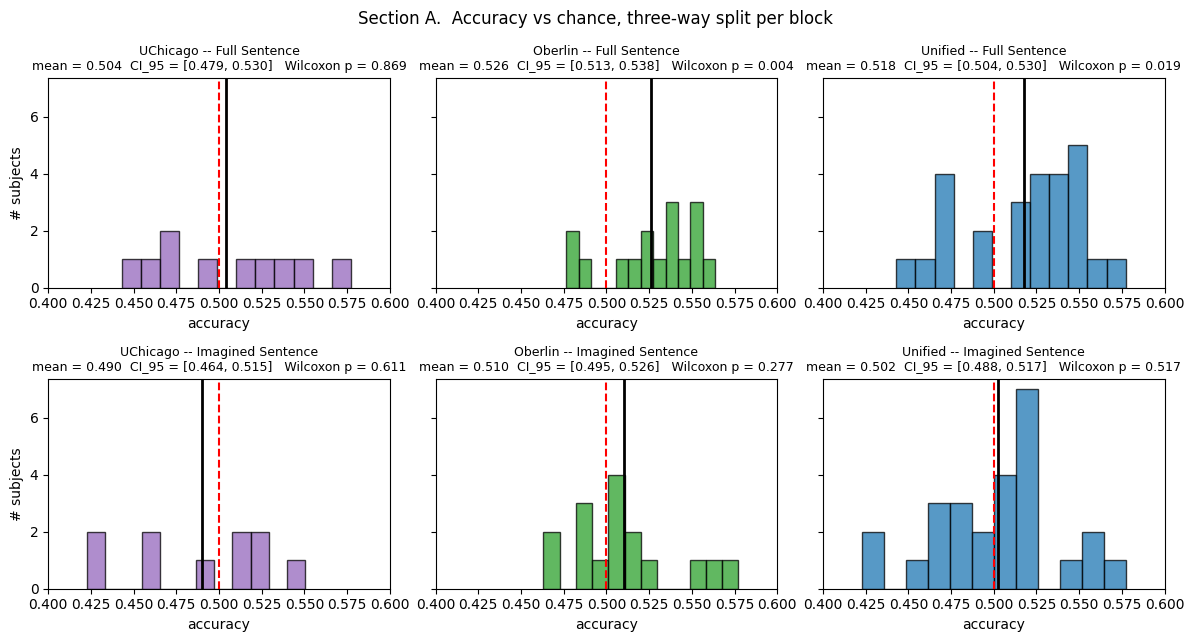

In [45]:
# ============================================================================
# Section A -- accuracy distribution figure (2 blocks x 3 groups)
#   Red dashed line  = chance (0.50)
#   Black solid line = group mean
# ============================================================================

# Setup the big plot to hold the 6 subplots (Full, Imagined) x (UChicago, Oberlin, Unified)
fig, axes_grid = plt.subplots(2, 3, figsize = (12, 6.5), sharey = True)

# Iterate over the results from above
for row_index, block_type in enumerate(("full_sentence", "imagined_sentence")):
    
    # Once again split the data into UChicago, Oberlin, and Unified
    groups_by_site = split_into_three_groups(per_subject_table, block_type)

    # Iterate over the splits and plot
    for col_index, group_name in enumerate(("UChicago", "Oberlin", "Unified")):
        
        # Setup the axis grid
        ax         = axes_grid[row_index, col_index]
        accuracies = groups_by_site[group_name]["accuracy"].values
        
        # Add a histogram
        ax.hist(accuracies, bins = 12, color = SITE_COLOR[group_name],
                 alpha = 0.75, edgecolor = "k")
        
        # Add the null hypothesis line at 0.5 accuracy
        ax.axvline(0.5, color = "red",   linestyle = "--", linewidth = 1.5)
        
        # Add the line with the observed group mean
        ax.axvline(np.mean(accuracies), color = "black", linewidth = 2)
        
        # Get the data from this block type and group split
        row = accuracy_vs_chance_table.query("block == @block_type and group == @group_name").iloc[0]
        
        # Label the graph
        ax.set_title(f"{group_name} -- {BLOCK_LABEL[block_type]}\n"
                      f"mean = {row['mean']:.3f}  "
                      f"CI_95 = [{row['ci_lo']:.3f}, {row['ci_hi']:.3f}]   "
                      f"Wilcoxon p = {row['wilcoxon_p']:.3f}", fontsize = 9)
        ax.set_xlabel("accuracy")

        # Add in the number of subjects
        if col_index == 0:
            ax.set_ylabel("# subjects")
        ax.set_xlim(0.40, 0.60)

# Add the overall graph title
plt.suptitle("Section A.  Accuracy vs chance, three-way split per block",fontsize = 12)

# Save the figure and display it too
plt.tight_layout()
plt.savefig(FIGURES_PATH / "A_accuracy_vs_chance.png", dpi = 140)
plt.show()


## 7.  Section B -- Full vs Imagined (paired)

Each subject ran both blocks.  Primary: paired Wilcoxon.  Also paired
$t$, sign-flip permutation $p$, and Cohen's $d$ on within-subject
differences.

In [46]:
# ============================================================================
# Section B -- table (Comparing accuracy for different block types)
# ============================================================================

print("\n=== Section B: full vs imagined (paired) ===")

# List to save our data to
full_vs_imagined_rows = []

# Iterate over the splits
for group_name in ("UChicago", "Oberlin", "Unified"):
    
    # Get the data for the split
    if group_name == "Unified":
        group_subset = per_subject_table
    else:
        group_subset = per_subject_table[per_subject_table["site"] == group_name]

    # Pivot so each subject is one row, with full and imagined accuracy as columns
    #   dropna() keeps only subjects who completed both blocks
    wide_per_subject = group_subset.pivot(index   = "subject",
                                           columns = "block_type",
                                           values  = "accuracy").dropna()

    # Extract the accuracy values for each block type
    accuracy_full     = wide_per_subject["full_sentence"].values
    accuracy_imagined = wide_per_subject["imagined_sentence"].values

    # Compute the within-subject difference (positive = full > imagined)
    differences = accuracy_full - accuracy_imagined

    # Paired Wilcoxon signed-rank test (primary): tests whether the median
    #   within-subject difference is zero, without assuming normality
    wilcoxon_stat, wilcoxon_p   = wilcoxon(differences)

    # Paired t-test: parametric alternative, assumes normally distributed differences
    paired_t_stat, paired_t_p   = ttest_rel(accuracy_full, accuracy_imagined)

    # Sign-flip permutation test: assumption-free p-value on the mean difference
    observed_diff, perm_p = permutation_test_mean_difference(accuracy_full, accuracy_imagined, paired = True)

    # Add all of the info for this group split to the list
    full_vs_imagined_rows.append(dict(
        group           = group_name,
        n               = len(differences),
        mean_full       = float(np.mean(accuracy_full)),
        mean_imag       = float(np.mean(accuracy_imagined)),
        mean_diff       = float(np.mean(differences)),
        sd_diff         = float(np.std(differences, ddof = 1)),
        wilcoxon_W      = float(wilcoxon_stat),
        wilcoxon_p      = float(wilcoxon_p),
        paired_t        = float(paired_t_stat),
        t_p             = float(paired_t_p),
        perm_p          = float(perm_p),
        cohens_d_paired = float(cohens_d_one_sample(differences, 0.0))))

# Cast list of values to a pandas dataframe, save to a CSV, and print some values as a sanity check
full_vs_imagined_table = pd.DataFrame(full_vs_imagined_rows)
full_vs_imagined_table.to_csv(TABLES_PATH / "B_full_vs_imagined.csv", index = False)
print(full_vs_imagined_table.round(4).to_string(index = False))


=== Section B: full vs imagined (paired) ===
   group  n  mean_full  mean_imag  mean_diff  sd_diff  wilcoxon_W  wilcoxon_p  paired_t    t_p  perm_p  cohens_d_paired
UChicago 10     0.5040     0.4899     0.0141   0.0643        21.0      0.5430    0.6936 0.5054  0.5083           0.2194
 Oberlin 16     0.5260     0.5101     0.0159   0.0462        32.5      0.2089    1.3811 0.1875  0.1976           0.3453
 Unified 26     0.5176     0.5023     0.0152   0.0526       100.5      0.1572    1.4766 0.1523  0.1582           0.2896


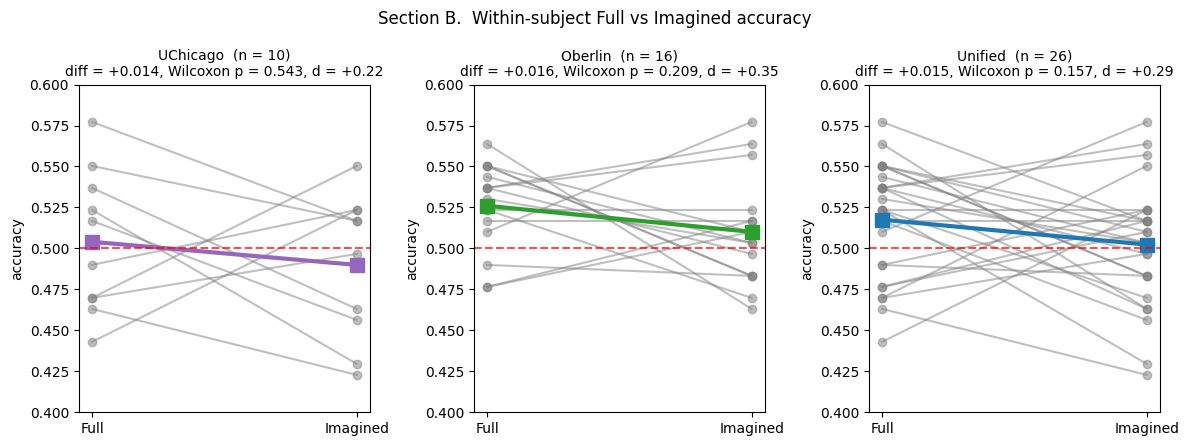

In [47]:
# ============================================================================
# Section B -- per-subject within-subject lines, one panel per group
# ============================================================================

# Setup the row of 3 subplots, one per group
fig, axes_row = plt.subplots(1, 3, figsize = (12, 4.5))

# Iterate over the splits
for ax, group_name in zip(axes_row, ("UChicago", "Oberlin", "Unified")):

    # Get the data for the split
    if group_name == "Unified":
        group_subset = per_subject_table
    else:
        group_subset = per_subject_table[per_subject_table["site"] == group_name]

    # Pivot so each subject is one row, with full and imagined accuracy as columns
    #   dropna() keeps only subjects who completed both blocks
    wide_per_subject = group_subset.pivot(index   = "subject",
                                           columns = "block_type",
                                           values  = "accuracy").dropna()

    # Draw one gray line per subject connecting their full and imagined accuracy
    for _, subject_row in wide_per_subject.iterrows():
        ax.plot([0, 1],
                 [subject_row["full_sentence"],
                  subject_row["imagined_sentence"]],
                 color = "gray", alpha = 0.5, marker = "o")

    # Draw the group mean line on top in the site color
    ax.plot([0, 1],
             [wide_per_subject["full_sentence"].mean(),
              wide_per_subject["imagined_sentence"].mean()],
             color = SITE_COLOR[group_name], linewidth = 3, marker = "s",
             markersize = 10, label = "group mean")

    # Add the null hypothesis line at 0.5 accuracy
    ax.axhline(0.5, color = "red", linestyle = "--", alpha = 0.7)

    # Pull the stats computed in the table cell above for the title
    row = full_vs_imagined_table.query("group == @group_name").iloc[0]

    # Label the subplot with key stats
    ax.set_title(f"{group_name}  (n = {int(row['n'])})\n"
                  f"diff = {row['mean_diff']:+.3f}, "
                  f"Wilcoxon p = {row['wilcoxon_p']:.3f}, "
                  f"d = {row['cohens_d_paired']:+.2f}", fontsize = 10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Full", "Imagined"])
    ax.set_ylabel("accuracy")
    ax.set_ylim(0.40, 0.60)

# Add the overall graph title
plt.suptitle("Section B.  Within-subject Full vs Imagined accuracy",
              fontsize = 12)

# Save the figure and display it too
plt.tight_layout()
plt.savefig(FIGURES_PATH / "B_full_vs_imagined.png", dpi = 140)
plt.show()

## 8.  Section C -- Oberlin vs UChicago (unpaired)

Per block.  Primary: Mann-Whitney $U$.  Also Welch $t$, shuffle
permutation $p$, pooled-SD Cohen's $d$.

In [48]:
# ============================================================================
# Section C -- table
# ============================================================================

print("\n=== Section C: Oberlin vs UChicago per block ===")

# Collect one row of stats per block type
site_comparison_rows = []
for block_type in ("full_sentence", "imagined_sentence"):

    # Filter to this block type, then split by site
    block_subset      = per_subject_table[per_subject_table["block_type"] == block_type]
    accuracy_oberlin  = block_subset[block_subset["site"] == "Oberlin"]["accuracy"].values
    accuracy_uchicago = block_subset[block_subset["site"] == "UChicago"]["accuracy"].values

    # Unpaired tests: Mann-Whitney U, Welch's t, and permutation
    mwu_stat, mwu_p = mannwhitneyu(accuracy_oberlin, accuracy_uchicago, alternative = "two-sided")
    welch_t_stat, welch_p = ttest_ind(accuracy_oberlin, accuracy_uchicago, equal_var = False)
    observed_diff, perm_p = permutation_test_mean_difference(accuracy_oberlin, accuracy_uchicago, paired = False)

    # Append results for this block type
    site_comparison_rows.append(dict(
        block         = block_type,
        n_oberlin     = len(accuracy_oberlin),
        n_uchicago    = len(accuracy_uchicago),
        mean_oberlin  = float(np.mean(accuracy_oberlin)),
        mean_uchicago = float(np.mean(accuracy_uchicago)),
        diff          = float(np.mean(accuracy_oberlin) - np.mean(accuracy_uchicago)),
        mwu_U         = float(mwu_stat),
        mwu_p         = float(mwu_p),
        welch_t       = float(welch_t_stat),
        welch_p       = float(welch_p),
        perm_p        = float(perm_p),
        cohens_d      = float(cohens_d_two_sample(accuracy_oberlin, accuracy_uchicago))))

# Cast to dataframe, save to CSV, and print
site_comparison_table = pd.DataFrame(site_comparison_rows)
site_comparison_table.to_csv(TABLES_PATH / "C_site_comparison.csv", index = False)
print(site_comparison_table.round(4).to_string(index = False))


=== Section C: Oberlin vs UChicago per block ===
            block  n_oberlin  n_uchicago  mean_oberlin  mean_uchicago   diff  mwu_U  mwu_p  welch_t  welch_p  perm_p  cohens_d
    full_sentence         16          10        0.5260         0.5040 0.0220  108.0 0.1453   1.4396   0.1733  0.1226    0.6493
imagined_sentence         16          10        0.5101         0.4899 0.0201   94.0 0.4751   1.2478   0.2309  0.2054    0.5388


/tmp/ipykernel_6922/1248849182.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels = box_labels, patch_artist = True, widths = 0.55, showfliers = False)
/tmp/ipykernel_6922/1248849182.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels = box_labels, patch_artist = True, widths = 0.55, showfliers = False)


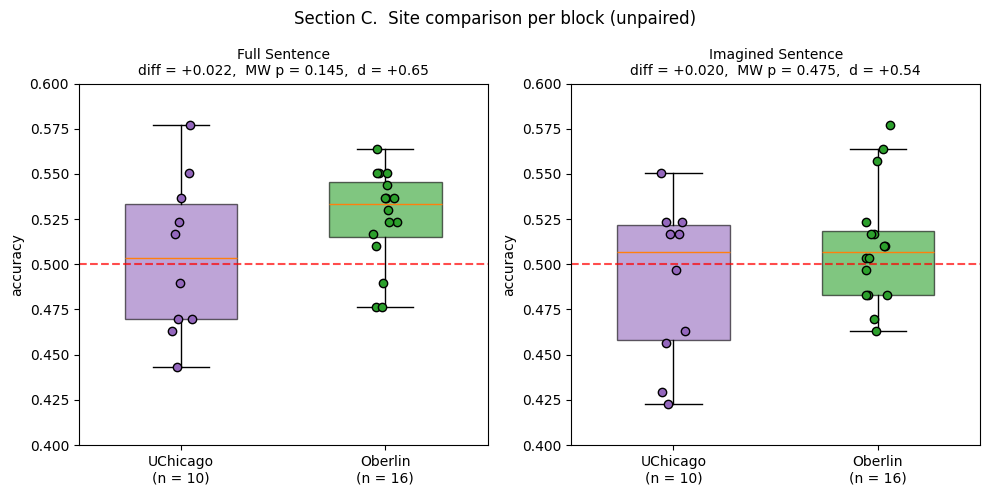

In [49]:
# ============================================================================
# Section C -- per-block site boxplots with overlaid jittered points
# ============================================================================

# Setup the row of 2 subplots, one per block type
fig, axes_row = plt.subplots(1, 2, figsize = (10, 5))

# Iterate over the block types
for ax, block_type in zip(axes_row, ("full_sentence", "imagined_sentence")):

    # Get all subjects for this block type
    block_subset = per_subject_table[per_subject_table["block_type"] == block_type]

    # Collect accuracy values, colors, and labels for each site
    box_data, box_colors, box_labels = [], [], []
    for site_name in ("UChicago", "Oberlin"):
        
        # Get the accuracies of the subjects
        accuracies = block_subset[block_subset["site"] == site_name]["accuracy"].values
        
        # Add to the box plot data
        box_data.append(accuracies)
        box_colors.append(SITE_COLOR[site_name])
        box_labels.append(f"{site_name}\n(n = {len(accuracies)})")

    # Draw the boxplots with filled patches
    bp = ax.boxplot(box_data, labels = box_labels, patch_artist = True, widths = 0.55, showfliers = False)

    # Color each box by site
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color); patch.set_alpha(0.6)

    # Overlay jittered individual subject points on top of each box
    for box_index, accuracies in enumerate(box_data):
        ax.scatter(np.full_like(accuracies, box_index + 1, dtype = float)
                    + RNG.uniform(-0.06, 0.06, size = len(accuracies)),
                    accuracies, color = box_colors[box_index],
                    edgecolor = "k", zorder = 3)

    # Add the null hypothesis line at 0.5 accuracy
    ax.axhline(0.5, color = "red", linestyle = "--", alpha = 0.7)

    # Pull the stats computed in the table cell above for the title
    row = site_comparison_table.query("block == @block_type").iloc[0]

    # Label the subplot with key stats
    ax.set_title(f"{BLOCK_LABEL[block_type]}\n"
                  f"diff = {row['diff']:+.3f},  "
                  f"MW p = {row['mwu_p']:.3f},  "
                  f"d = {row['cohens_d']:+.2f}", fontsize = 10)
    ax.set_ylabel("accuracy")
    ax.set_ylim(0.40, 0.60)

# Add the overall graph title
plt.suptitle("Section C.  Site comparison per block (unpaired)",
              fontsize = 12)

# Save the figure and display it too
plt.tight_layout()
plt.savefig(FIGURES_PATH / "C_site_comparison.png", dpi = 140)
plt.show()

## 9.  Section D -- block order

Per (block, group): subjects who ran the block FIRST vs SECOND.
Mann-Whitney $U$.  Cells with fewer than 3 subjects on either side are
skipped (no $p$).

In [50]:
# ============================================================================
# Section D -- table
# ============================================================================

print("\n=== Section D: block order ===")

# Collect one row of stats per (block_type, group)
block_order_rows = []
for block_type in ("full_sentence", "imagined_sentence"):

    # Split into the same three groups used elsewhere (UChicago / Oberlin / Unified)
    groups_by_site = split_into_three_groups(per_subject_table, block_type)

    # For each group, compare subjects who did this block first vs second
    for group_name, group_subset in groups_by_site.items():

        # Pull accuracies for subjects where this block was first vs second
        accuracy_first  = group_subset[group_subset["block_order_index"] == 1]["accuracy"].dropna().values
        accuracy_second = group_subset[group_subset["block_order_index"] == 2]["accuracy"].dropna().values

        # If sample sizes are tiny, record means but skip inference stats
        if len(accuracy_first) < 3 or len(accuracy_second) < 3:
            block_order_rows.append(dict(
                block    = block_type,
                group    = group_name,
                n_b1     = len(accuracy_first),
                n_b2     = len(accuracy_second),
                mean_b1  = (float(np.mean(accuracy_first))  if len(accuracy_first) else np.nan),
                mean_b2  = (float(np.mean(accuracy_second)) if len(accuracy_second) else np.nan),
                mwu_p    = np.nan,
                cohens_d = np.nan))
            continue

        # Unpaired comparison: Mann–Whitney U (block first vs block second)
        mwu_stat, mwu_p = mannwhitneyu(accuracy_first, accuracy_second, alternative = "two-sided")

        # Record summary stats + effect size (Cohen's d; sign tracks mean(second) - mean(first))
        block_order_rows.append(dict(
            block    = block_type,
            group    = group_name,
            n_b1     = len(accuracy_first),
            n_b2     = len(accuracy_second),
            mean_b1  = float(np.mean(accuracy_first)),
            mean_b2  = float(np.mean(accuracy_second)),
            mwu_p    = float(mwu_p),
            cohens_d = float(cohens_d_two_sample(accuracy_second, accuracy_first))))

# Cast to dataframe, save to CSV, and print
block_order_table = pd.DataFrame(block_order_rows)
block_order_table.to_csv(TABLES_PATH / "D_block_order.csv", index = False)
print(block_order_table.round(4).to_string(index = False))


=== Section D: block order ===
            block    group  n_b1  n_b2  mean_b1  mean_b2  mwu_p  cohens_d
    full_sentence UChicago     4     6   0.5000   0.5067 0.8307    0.1458
    full_sentence  Oberlin     5    11   0.5195   0.5290 0.4935    0.3539
    full_sentence  Unified     9    17   0.5108   0.5211 0.4323    0.2923
imagined_sentence UChicago     6     4   0.4899   0.4899 0.9146    0.0000
imagined_sentence  Oberlin    11     5   0.5003   0.5315 0.0776    1.0343
imagined_sentence  Unified    17     9   0.4966   0.5130 0.1850    0.4332


## 10.  Section E -- convergent metrics, computed from raw audio

Five mathematically distinct per-subject quantities, computed here
from raw trial CSVs and raw WAV files.  Reported in the
**full_sentence** block, three-way split.

- $d'$ -- already computed above.
- accuracy -- already computed above.
- $\cos(\mathrm{CI}_s, \mathrm{CI}_{\rm true})$ -- raw-waveform classification image.
- $\cos(w_s, w_{\rm true})$ -- 32-band log-magnitude spectral template.
- $\beta_{\text{truetarget}}$ -- per-subject logistic regression
  coefficient on the experimenter label, controlling for trial position.

In [51]:
# ============================================================================
# Load every full-sentence stimulus WAV.
#   Filenames in raw_data/audio_stimuli/<block>/{targets,distractors}/
#   match the integer "Stimulus Number" in the trial CSVs.
# ============================================================================

def load_block_stimuli(block_type):
    # Return two dicts keyed by stimulus id (filename stem):
    #   1) waveform_by_id: stim_id -> 1D float64 waveform
    #   2) label_by_id:    stim_id -> {"target","distractor"}
    waveform_by_id = {}
    label_by_id    = {}

    # Root folder for this block type (e.g., full_sentence)
    block_root = AUDIO_STIM_PATH / block_type

    # Iterate over the two label subfolders and assign a short label
    for label_dir, label_short in (("targets", "target"), ("distractors", "distractor")):

        # Load every .wav in this label directory (sorted for determinism)
        for wav_path in sorted((block_root / label_dir).glob("*.wav")):

            # Stimulus id is the filename stem (should match trial CSV ids)
            stim_id = wav_path.stem

            # Read audio; sf.read returns (waveform, sample_rate)
            waveform, _ = sf.read(wav_path)

            # If stereo/multi-channel, downmix to mono by averaging channels
            if waveform.ndim != 1:
                print(f"Audio sample not Mono: {wav_path}")

            # Store as float64 for downstream numeric stability/consistency
            waveform_by_id[stim_id] = waveform.astype(np.float64)
            label_by_id   [stim_id] = label_short

    return waveform_by_id, label_by_id


# Load the full-sentence stimulus set into memory
full_sentence_waveform_by_id, full_sentence_label_by_id = load_block_stimuli("full_sentence")

# Quick sanity check: how many files and what sample-length range?
waveform_lengths = [len(waveform) for waveform in full_sentence_waveform_by_id.values()]
assert all([waveform_length == waveform_lengths[0] for waveform_length in waveform_lengths])
print(f"Loaded {len(full_sentence_waveform_by_id)} full_sentence WAVs, "
      f"Confirmed that all waveforms have {waveform_lengths[0]} samples")

Loaded 150 full_sentence WAVs, Confirmed that all waveforms have 2960 samples


In [52]:
# ============================================================================
# Per-subject classification image cosine.
#   CI_subject = mean(waveform | called target) - mean(waveform | called distractor)
#   CI_true    = mean(waveform | true  target) - mean(waveform | true  distractor)
#   metric     = cos(CI_subject, CI_true)
# ============================================================================

def _stack_waveforms(waveforms):

    # Stack all waveforms to get a nice big matrix we can operate over
    assert all(len(waveform) == len(waveforms[0]) for waveform in waveforms)
    return np.stack([wav for wav in waveforms], axis = 0)


def _cosine_similarity(a, b):

    # Cast the two waveforms to vectors
    a = np.asarray(a, dtype = float)
    b = np.asarray(b, dtype = float)

    # Get the magnitudes of each so we can normalize to magnitude = 1
    denom = np.linalg.norm(a) * np.linalg.norm(b)

    # Calculate cosine similarity
    #   Results in nan if the denominator = 0
    if denom > 0:
        cosine_sim = float(np.dot(a, b) / denom) 
    else:
        cosine_sim = np.nan

    return cosine_sim


def compute_classification_image_cosine(block_trials, waveform_by_id):
    # Collect waveforms split by:
    #   - true label (stimulus_type)
    #   - subject's response (subject_response... how they "called" it)
    target_waveforms_true,    distractor_waveforms_true   = [], []
    target_waveforms_called,  distractor_waveforms_called = [], []

    for trial in block_trials.itertuples(index = False):
        
        # Look up the stimulus waveform for this trial
        wav = waveform_by_id.get(trial.stimulus_number)
        if wav is None:
            print(f"Broken Path: {waveform_by_id.get(trial.stimulus_number)}")

        # Split by true stimulus label
        # Adds to list of targets if it is a target
        # Otherwise we add it to the distractors
        if trial.stimulus_type == "target":
            target_waveforms_true.append(wav)
        else:
            distractor_waveforms_true.append(wav)

        # Split by what the subject called it
        # If subject said it was a target, then add to "target_waveforms_called"
        # Otherwise, add to "distractor_waveforms_called"
        if trial.subject_response == "target":
            target_waveforms_called.append(wav)
        else:
            distractor_waveforms_called.append(wav)

    # If any either bucket is empty, then we can't form both templates so both are NaN
    if not (target_waveforms_called and distractor_waveforms_called and target_waveforms_true and distractor_waveforms_true):
        return np.nan

    # Compute "classification image" templates as mean(target) - mean(distractor)
    ci_true     = (_stack_waveforms(target_waveforms_true).mean(axis = 0)
                 - _stack_waveforms(distractor_waveforms_true).mean(axis = 0))    
    ci_subject  = (_stack_waveforms(target_waveforms_called).mean(axis = 0)
                 - _stack_waveforms(distractor_waveforms_called).mean(axis = 0))

    # Ensure equal length before cosine
    assert(len(ci_true) == len(ci_subject))
    
    # Get cosine similarity and return
    cosine_similarity = _cosine_similarity(ci_true, ci_subject)
    return cosine_similarity

In [53]:
# ============================================================================
# Per-subject reminder-anchored logistic.
#   called_target ~ logistic(intercept + b_true * is_target_true + b_pos * trial_index_normalized)
#   beta_truetarget = fitted coefficient on is_target_true.
# Sklearn LogisticRegression with no penalty (solver = lbfgs).
# ============================================================================

# TODO: Double check whether we index trials via 0 or 1
def compute_beta_truetarget(block_trials):

    # Total number of trials for a given block
    #  Assert each block used has 149 trials
    n_trials = len(block_trials)
    assert n_trials == 149
    
    # Actual label for the stimulus ("Target" vs "Distractor")
    is_target_true = block_trials["is_target_true"].values.astype(float)

    # Trial index as a proportion from 0 to 1 (inclusive) which we can interpret 
    #   as "percent" way through the block  
    trial_position = (block_trials["trial_index"].values / max(n_trials - 1, 1))

    # Whether the subject called the stimulus as a target or a distractor
    called_target  = block_trials["called_target"].values.astype(int)
    
    # Ensure the subject did not just pick one response for the entire task
    assert len(set(called_target)) == 2 

    # Create a matrix with two columns: one for the actual label and 
    #   the second what percent the way through the block that the 
    #   stimulus was presented on  
    feature_matrix = np.column_stack([is_target_true, trial_position])

    # Sklearn LogisticRegression with no penalty (C = inf, solver = lbfgs)
    # Supress annoying sklearn warning (they screwed something up)
    model = LogisticRegression(C = 10**9, solver = "lbfgs", max_iter = 10**6)
    model.fit(feature_matrix, called_target)
    return float(model.coef_[0, 0])


In [54]:
# ============================================================================
# Compute the four "raw-data" metrics for every (subject, full_sentence) cell.
#   d' and accuracy are already in per_subject_table.
# ============================================================================

print("\nComputing per-subject CI cosine, spectral cosine, and beta_truetarget for the full_sentence block ...")

# List to store convergent metrics results
metric_rows = []

# Get all trials where the block type is full sentence
full_sentence_trials = trial_table[trial_table["block_type"] == "full_sentence"]

# Group by experimental site and subject, calculate all of the convergent metrics and store in the data list
for (site, subject), subject_trials in full_sentence_trials.groupby(["site", "subject"]):
    metric_rows.append(dict(
        site            = site,
        subject         = subject,
        block_type      = "full_sentence",
        cos_ci_true     = compute_classification_image_cosine(subject_trials, full_sentence_waveform_by_id),
        beta_truetarget = compute_beta_truetarget(subject_trials)))

# Cast the data in the list to a pandas dataframe
per_subject_metrics_table = pd.DataFrame(metric_rows)

# Merge these new rows by using the experimental site, subject number and block type as the unique identifiers
per_subject_metrics_table = per_subject_metrics_table.merge(
    per_subject_table[["site", "subject", "block_type", "accuracy", "d_prime"]],
    on = ["site", "subject", "block_type"], how = "left")

# Save the table with each block's complete computed data
per_subject_metrics_table.to_csv(TABLES_PATH / "E_per_subject_full_sentence_metrics.csv", index = False)
print(f"computed {len(per_subject_metrics_table)} subject rows")
per_subject_metrics_table.head()



Computing per-subject CI cosine, spectral cosine, and beta_truetarget for the full_sentence block ...
computed 26 subject rows


,site,subject,block_type,cos_ci_true,beta_truetarget,accuracy,d_prime
0,Oberlin,02242025001,full_sentence,0.006762,-0.190044,0.476510,-0.119199
1,Oberlin,02262025001,full_sentence,0.039026,0.231855,0.530201,0.152622
2,Oberlin,03032025001,full_sentence,0.031621,0.169436,0.523490,0.123422
3,Oberlin,03032025002,full_sentence,0.040391,0.139808,0.510067,0.050154
4,Oberlin,03062025001,full_sentence,0.097938,0.408628,0.550336,0.252859


In [55]:
# ============================================================================
# Section E -- convergent metrics summary table
# ============================================================================

print("\n=== Section E: convergent metrics, full_sentence ===")

CONVERGENT_METRICS = [
    ("d_prime",         "d'  (SDT sensitivity)",                0.0),
    ("accuracy",        "accuracy",                             0.5),
    ("cos_ci_true",     "cos(CI_subject, CI_true)",             0.0),
    ("beta_truetarget", "beta_truetarget (per-subject logit)",  0.0),
]

convergent_rows = []
for group_name in ("UChicago", "Oberlin", "Unified"):
    group_subset = per_subject_metrics_table
    if group_name != "Unified":
        group_subset = group_subset[group_subset["site"] == group_name]
    for metric_column, metric_label, null_value in CONVERGENT_METRICS:
        metric_values = group_subset[metric_column].dropna().values
        try:
            wilcoxon_stat, wilcoxon_p = wilcoxon(metric_values - null_value)
        except ValueError:
            wilcoxon_stat, wilcoxon_p = (np.nan, np.nan)
        t_stat, t_p   = ttest_1samp(metric_values, null_value)
        mean_v, lo, hi = bootstrap_ci_of_mean(metric_values)
        convergent_rows.append(dict(
            group      = group_name,
            metric     = metric_column,
            label      = metric_label,
            n          = len(metric_values),
            null       = null_value,
            mean       = mean_v,
            ci_lo      = lo,
            ci_hi      = hi,
            wilcoxon_W = (float(wilcoxon_stat) if not np.isnan(wilcoxon_stat) else np.nan),
            wilcoxon_p = (float(wilcoxon_p) if not np.isnan(wilcoxon_p) else np.nan),
            t          = float(t_stat),
            t_p        = float(t_p),
            cohens_d   = float(cohens_d_one_sample(metric_values, null_value))))

convergent_metrics_table = pd.DataFrame(convergent_rows)
convergent_metrics_table.to_csv(TABLES_PATH / "E_convergent_full_sentence.csv", index = False)
print(convergent_metrics_table.round(4)[["group", "metric", "n", "mean", "ci_lo", "ci_hi", "wilcoxon_p", "cohens_d"]].to_string(index = False))



=== Section E: convergent metrics, full_sentence ===
   group          metric  n    mean   ci_lo  ci_hi  wilcoxon_p  cohens_d
UChicago         d_prime 10  0.0209 -0.1065 0.1533      0.8457    0.0941
UChicago        accuracy 10  0.5040  0.4792 0.5302      0.8691    0.0925
UChicago     cos_ci_true 10 -0.0020 -0.0585 0.0555      1.0000   -0.0209
UChicago beta_truetarget 10  0.0421 -0.1594 0.2477      0.8457    0.1213
 Oberlin         d_prime 16  0.1373  0.0692 0.2004      0.0013    0.9908
 Oberlin        accuracy 16  0.5260  0.5130 0.5378      0.0037    0.9858
 Oberlin     cos_ci_true 16  0.0564  0.0295 0.0830      0.0013    0.9997
 Oberlin beta_truetarget 16  0.2323  0.1180 0.3397      0.0027    0.9916
 Unified         d_prime 26  0.0925  0.0230 0.1589      0.0130    0.5127
 Unified        accuracy 26  0.5176  0.5041 0.5305      0.0185    0.5027
 Unified     cos_ci_true 26  0.0339  0.0037 0.0627      0.0254    0.4320
 Unified beta_truetarget 26  0.1591  0.0472 0.2667      0.0163    0.54

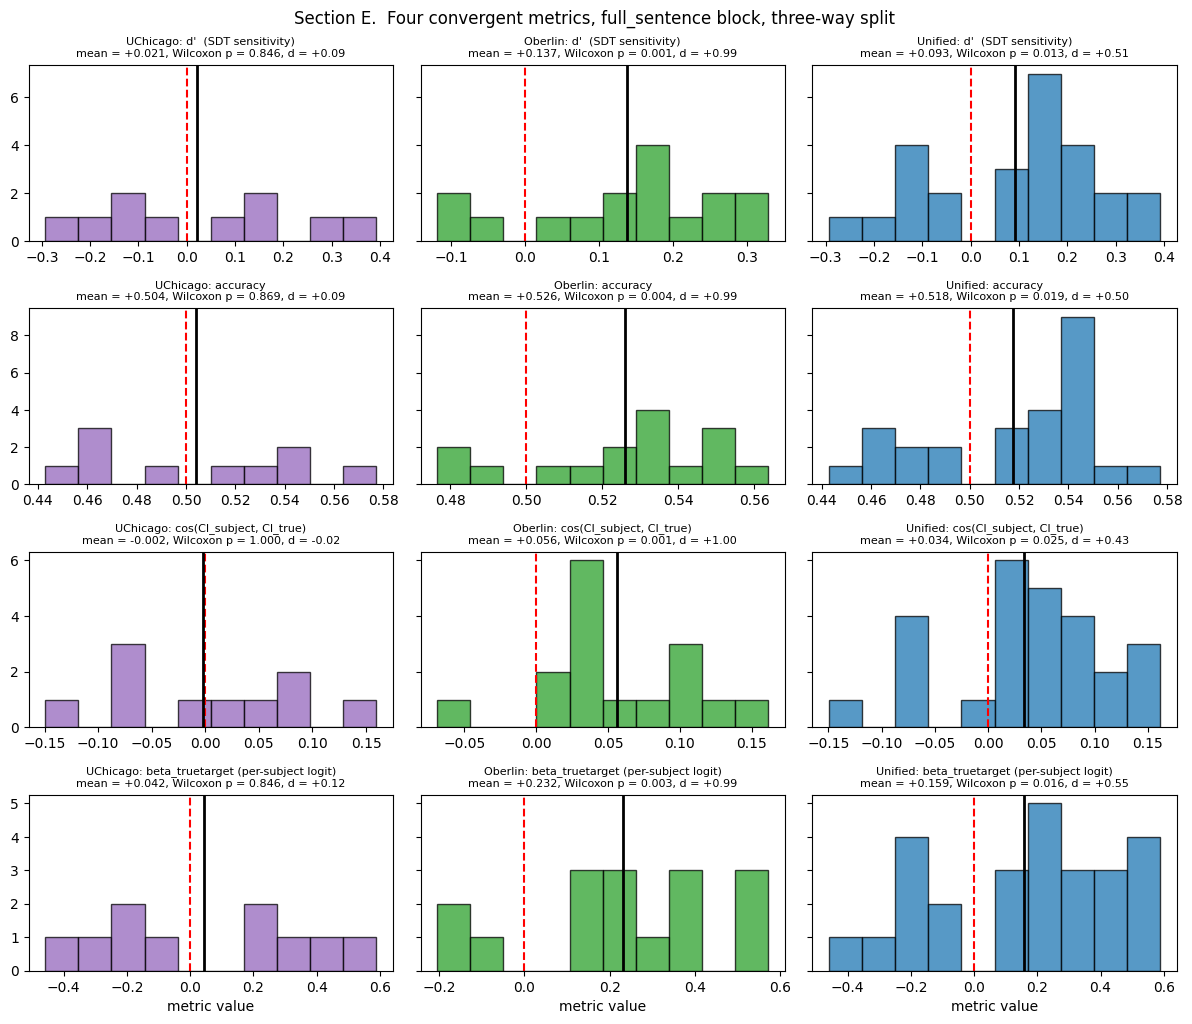

In [60]:
# ============================================================================
# Section E -- 5x3 grid of histograms
#   Rows = metric.  Columns = UChicago / Oberlin / Unified.
#   Red dashed = null value (0 or 0.5).  Black = group mean.
# ============================================================================

# Setup the big grid: one row per metric, one column per site split
fig, axes_grid = plt.subplots(len(CONVERGENT_METRICS), 3,
                               figsize = (12, 2.6 * len(CONVERGENT_METRICS)),
                               sharey = "row")

# Iterate over each metric (row) and each site split (column)
for row_index, (metric_column, metric_label, null_value) in enumerate(CONVERGENT_METRICS):
    for col_index, group_name in enumerate(("UChicago", "Oberlin", "Unified")):
        ax = axes_grid[row_index, col_index]

        # Filter to this site (Unified = all subjects pooled)
        group_subset = per_subject_metrics_table
        if group_name != "Unified":
            group_subset = group_subset[group_subset["site"] == group_name]

        # Drop subjects missing this metric, then plot the distribution
        metric_values = group_subset[metric_column].dropna().values
        ax.hist(metric_values, bins = 10, color = SITE_COLOR[group_name], alpha = 0.75, edgecolor = "k")

        # Add the null hypothesis line (0 for d-type metrics, 0.5 for accuracy)
        ax.axvline(null_value, color = "red", linestyle = "--", linewidth = 1.5)

        # Add the observed group mean
        ax.axvline(np.mean(metric_values), color = "black", linewidth = 2)

        # Pull the pre-computed stats for the title
        row = convergent_metrics_table.query("group == @group_name and metric == @metric_column").iloc[0]
        ax.set_title(f"{group_name}: {metric_label}\n"
                      f"mean = {row['mean']:+.3f}, "
                      f"Wilcoxon p = {row['wilcoxon_p']:.3f}, "
                      f"d = {row['cohens_d']:+.2f}", fontsize = 8)

        # Only label the x-axis on the bottom row
        if row_index == len(CONVERGENT_METRICS) - 1:
            ax.set_xlabel("metric value")

# Add the overall graph title, save and show
plt.suptitle("Section E.  Four convergent metrics, full_sentence block, ""three-way split", fontsize = 12)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "E_convergent_full_sentence.png", dpi = 140)
plt.show()

## 11.  Section F -- questionnaire correlations (exploratory)

Spearman $\rho$ between each questionnaire and accuracy, in each
(block, group).  $8 \times 2 \times 3 = 48$ correlations.  Bonferroni
at $\alpha = 0.05$ requires $p < 1.04 \times 10^{-3}$.

In [57]:
# ============================================================================
# Section F -- Spearman correlation table
# ============================================================================

print("\n=== Section F: questionnaire vs accuracy ===")

# Collect one row per (block, questionnaire, group) combination
questionnaire_correlation_rows = []
for block_type in ("full_sentence", "imagined_sentence"):

    # Split subjects into the same three groups used elsewhere
    groups_by_site = split_into_three_groups(per_subject_table, block_type)

    # Iterate over the questionnaires
    for questionnaire_name in QUESTIONNAIRE_COLUMNS:
        for group_name, group_subset in groups_by_site.items():

            # Pull questionnaire and accuracy values for this group
            quest_values    = group_subset[questionnaire_name].values
            accuracy_values = group_subset["accuracy"].values

            # Drop any subject missing either value; skip if fewer than 4 remain
            valid = ~(np.isnan(quest_values) | np.isnan(accuracy_values))
            if valid.sum() < 4:
                continue

            # Spearman rho (non-parametric; appropriate for ordinal questionnaires)
            spearman_rho, spearman_p = spearmanr(quest_values[valid], accuracy_values[valid])
            questionnaire_correlation_rows.append(dict(
                block = block_type,
                group = group_name,
                quest = questionnaire_name,
                n     = int(valid.sum()),
                rho   = float(spearman_rho),
                p     = float(spearman_p)))

# Cast to dataframe, save to CSV, and print the top 20 by p-value
questionnaire_correlation_table = pd.DataFrame(questionnaire_correlation_rows)
questionnaire_correlation_table.to_csv(TABLES_PATH / "F_questionnaire_spearman.csv", index = False)
print(questionnaire_correlation_table.sort_values("p").head(20).round(4).to_string(index = False))


=== Section F: questionnaire vs accuracy ===
            block    group    quest  n     rho      p
    full_sentence  Unified   BAIS_C 26  0.3113 0.1216
    full_sentence UChicago     LSHS 10  0.5199 0.1235
    full_sentence  Oberlin      FSS 16  0.3723 0.1556
    full_sentence UChicago   BAIS_C 10  0.4801 0.1602
    full_sentence  Unified   BAIS_V 26  0.2779 0.1693
    full_sentence  Unified      FSS 26  0.2774 0.1701
    full_sentence  Oberlin   BAIS_C 16  0.3551 0.1771
    full_sentence  Unified      DES 26  0.2234 0.2727
    full_sentence UChicago   BAIS_V 10  0.3647 0.3001
imagined_sentence UChicago      TAS 10  0.3537 0.3161
    full_sentence  Oberlin   BAIS_V 16  0.2667 0.3181
imagined_sentence  Oberlin      DES 16 -0.2648 0.3216
imagined_sentence UChicago      FSS 10  0.3468 0.3263
    full_sentence  Oberlin SSS_mean 16 -0.2509 0.3485
imagined_sentence UChicago      DES 10  0.3272 0.3561
imagined_sentence  Unified   BAIS_C 26  0.1787 0.3823
    full_sentence UChicago      DES 

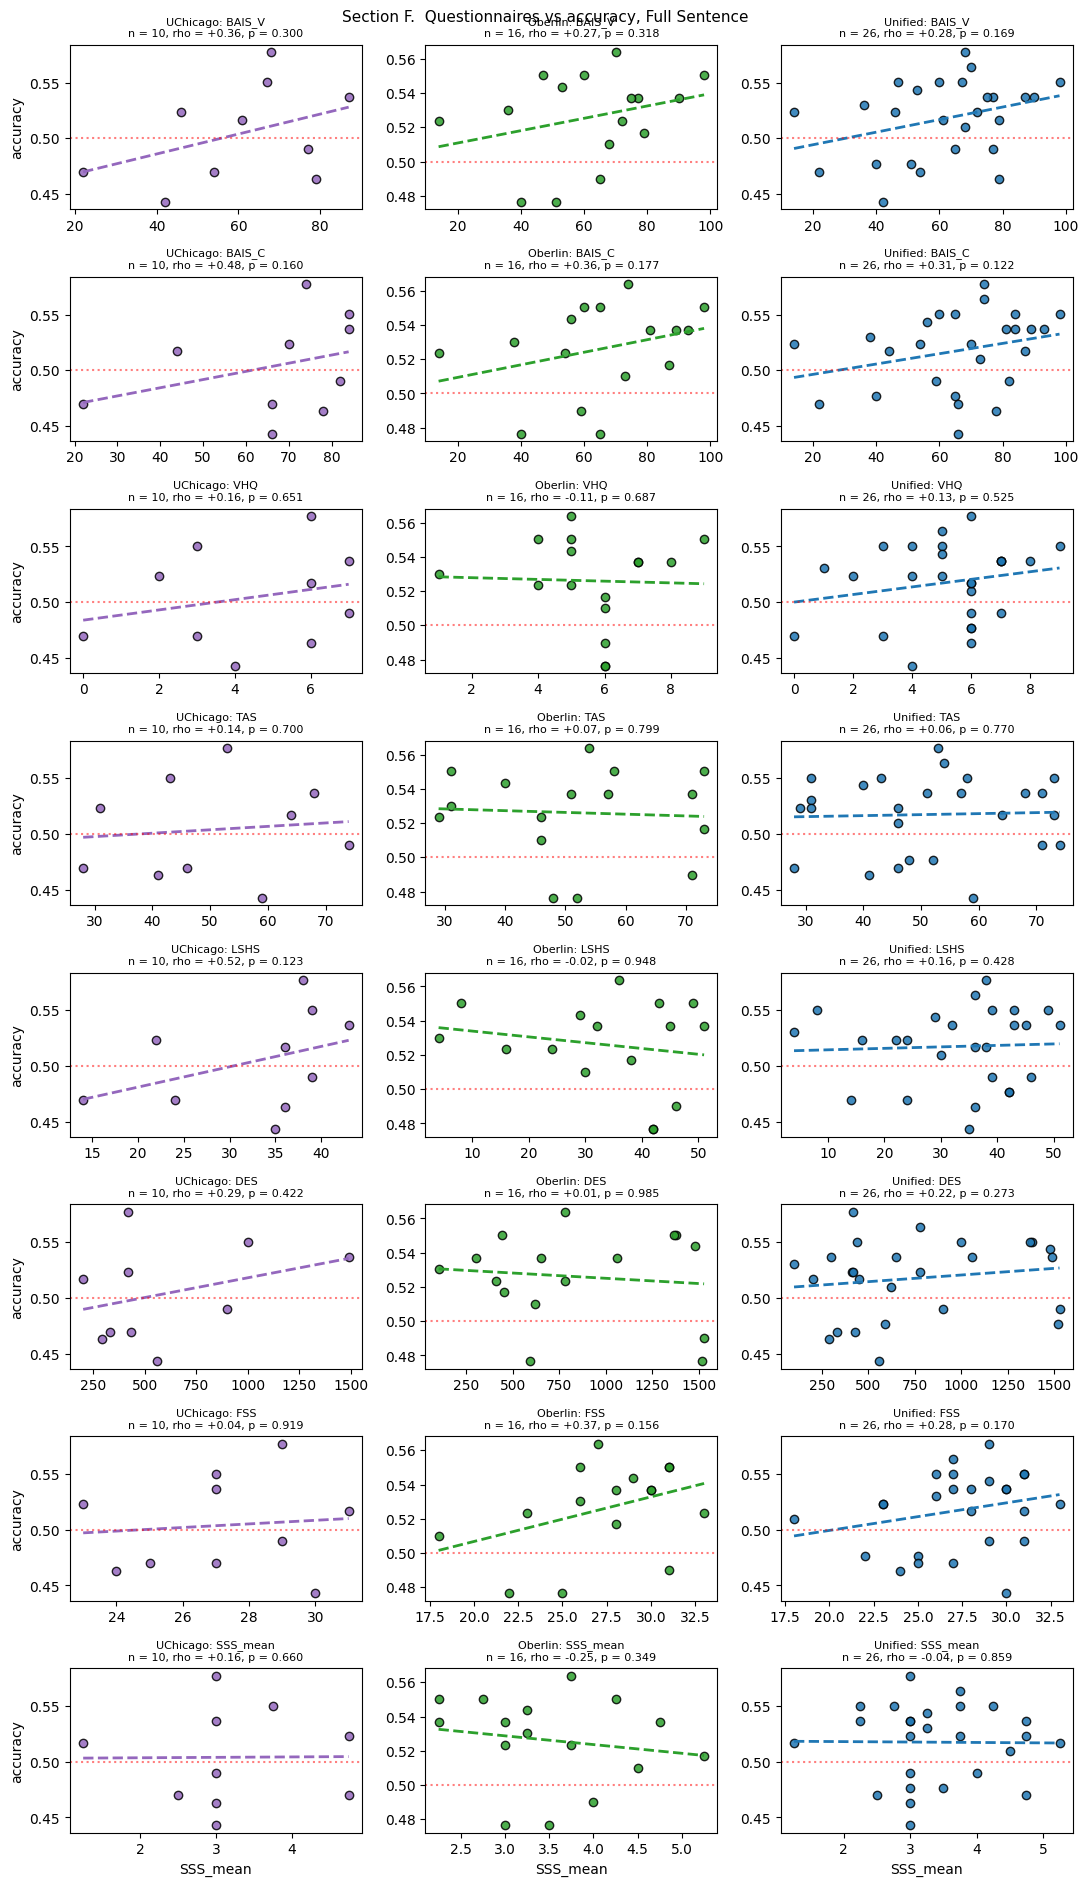

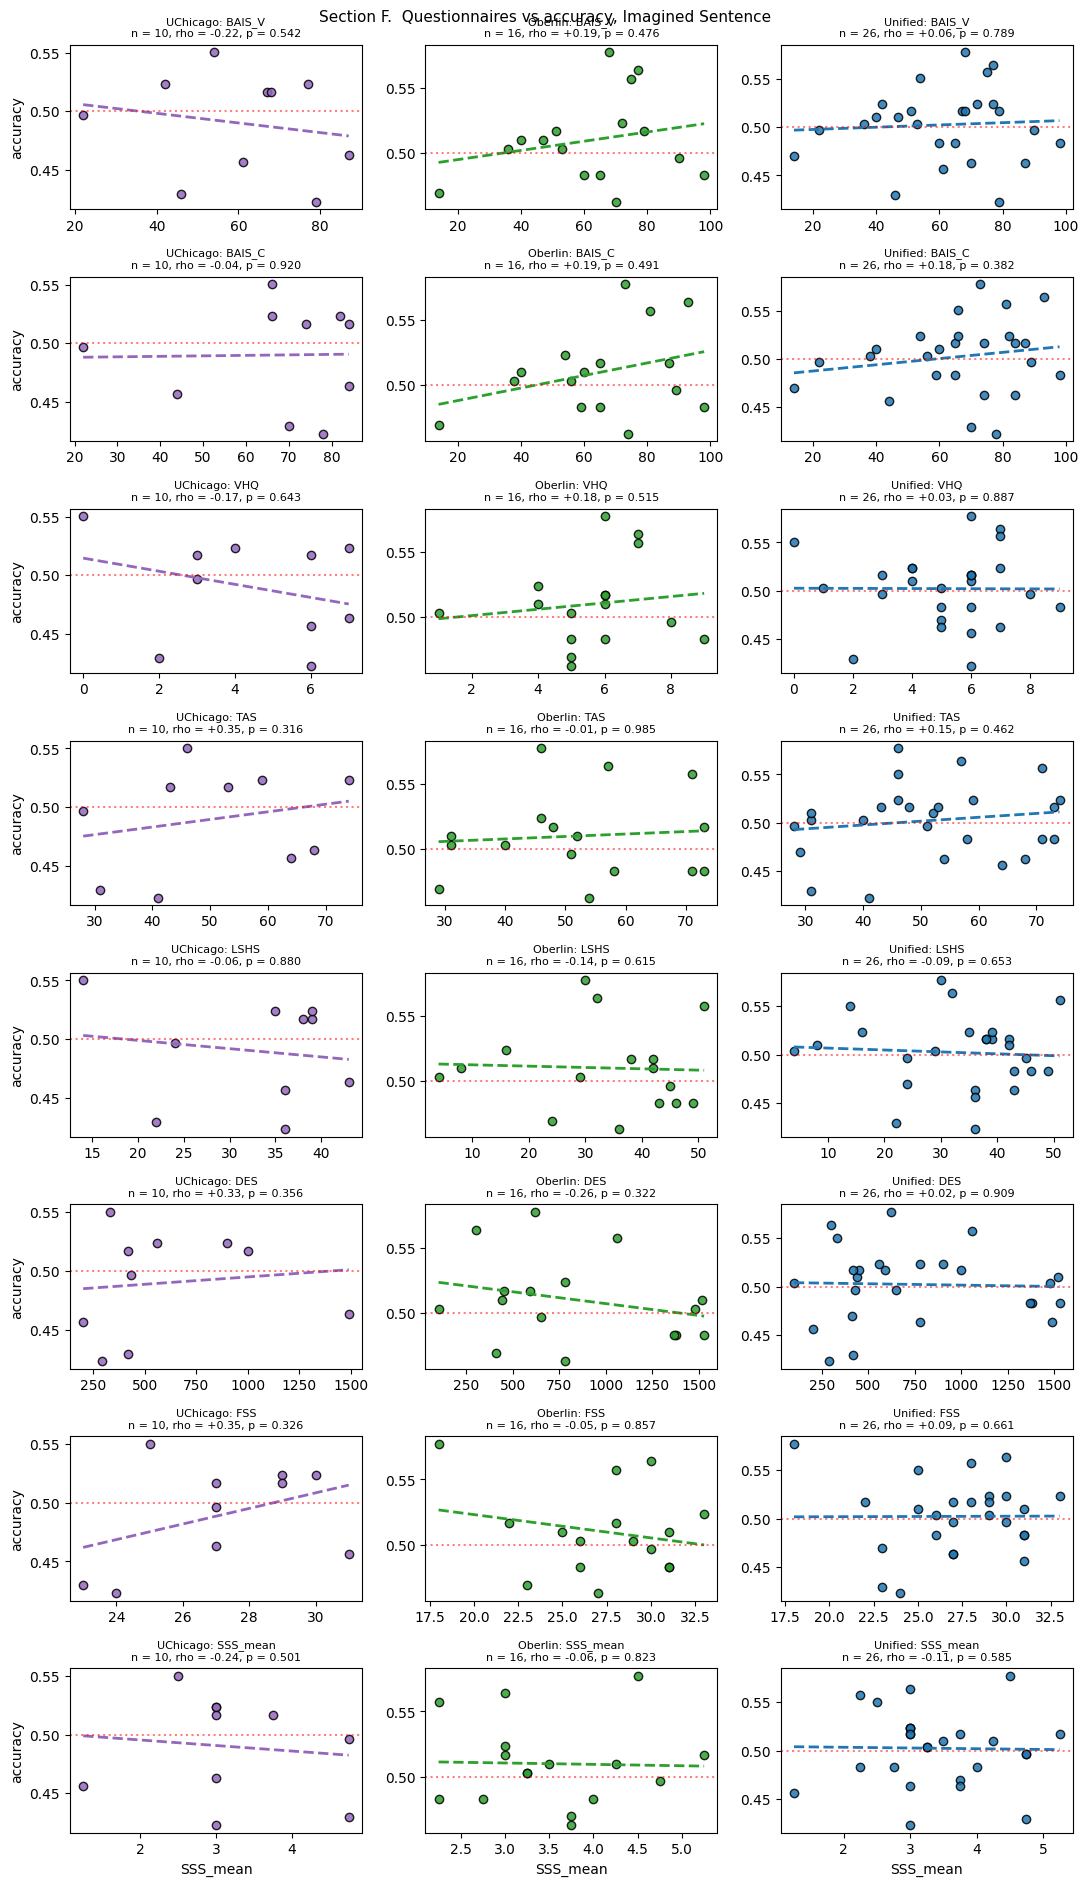

In [58]:
# ============================================================================
# Section F -- one figure per block.
#   Grid: rows = questionnaires, cols = group.
#   Each panel has its OWN scatter and its OWN OLS line (no overlay).
# ============================================================================

# One figure per block type
for block_type in ("full_sentence", "imagined_sentence"):

    # Setup the grid: one row per questionnaire, one column per site split
    fig, axes_grid = plt.subplots(len(QUESTIONNAIRE_COLUMNS), 3, figsize = (11, 2.4 * len(QUESTIONNAIRE_COLUMNS)))
    groups_by_site = split_into_three_groups(per_subject_table, block_type)

    # Iterate over each questionnaire (row) and site split (column)
    for row_index, questionnaire_name in enumerate(QUESTIONNAIRE_COLUMNS):
        for col_index, group_name in enumerate(("UChicago", "Oberlin", "Unified")):
            ax           = axes_grid[row_index, col_index]
            group_subset = groups_by_site[group_name]

            # Pull values and drop subjects missing either measure
            quest_values    = group_subset[questionnaire_name].values
            accuracy_values = group_subset["accuracy"].values
            valid           = ~(np.isnan(quest_values) | np.isnan(accuracy_values))
            xs = quest_values   [valid]
            ys = accuracy_values[valid]

            # Scatter the individual subjects
            ax.scatter(xs, ys, color = SITE_COLOR[group_name], edgecolor = "k", alpha = 0.85)

            # Overlay an OLS trend line if there are enough points and variance
            if len(xs) >= 3 and np.ptp(xs) > 0:
                slope, intercept = np.polyfit(xs, ys, 1)
                line_x = np.array([xs.min(), xs.max()])
                ax.plot(line_x, slope * line_x + intercept, color = SITE_COLOR[group_name], linestyle = "--", linewidth = 2)

            # Spearman rho for the title (needs at least 4 valid pairs)
            spearman_rho, spearman_p = (spearmanr(xs, ys) if len(xs) >= 4 else (np.nan, np.nan))

            # Add the null accuracy line at 0.5
            ax.axhline(0.5, color = "red", linestyle = ":", alpha = 0.5)

            ax.set_title(f"{group_name}: {questionnaire_name}\n"
                          f"n = {len(xs)}, "
                          f"rho = {spearman_rho:+.2f}, "
                          f"p = {spearman_p:.3f}", fontsize = 8)

            # Only label the y-axis on the left column and x-axis on the bottom row
            if col_index == 0:
                ax.set_ylabel("accuracy")
            if row_index == len(QUESTIONNAIRE_COLUMNS) - 1:
                ax.set_xlabel(questionnaire_name)

    # Add the overall graph title, save and show
    plt.suptitle(f"Section F.  Questionnaires vs accuracy, "f"{BLOCK_LABEL[block_type]}", fontsize = 11)
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / f"F_quest_vs_accuracy_{block_type}.png",dpi = 130)
    plt.show()

## 12.  Section G -- sub-sample power diagnostics

For each "trending" comparison: at the observed effect, would more
subjects have made this significant?  At each candidate sub-sample
size $n$, draw 2000 random subsets of that size from the observed
data, run the relevant test, record the fraction with $p < 0.05$.

- **G1.**  Oberlin full_sentence accuracy vs chance (one-sample Wilcoxon).
- **G2.**  Site difference, full_sentence (unpaired Mann-Whitney; preserves Oberlin/UChicago ratio).
- **G3.**  Full vs Imagined paired (paired Wilcoxon on within-subject differences).

In [65]:
# ============================================================================
# Sub-sample power -- one-sample Wilcoxon
# ============================================================================

def subsample_power_one_sample(values, null_mean = 0.5, sub_sample_sizes = None, n_resample = 2000, alpha = 0.05, rng = RNG):
    
    # Default: sweep from n = 5 up to the full observed sample, in steps of 2
    if sub_sample_sizes is None:
        sub_sample_sizes = list(range(5, len(values) + 1, 2))
        
    rows = []
    # For each candidate sub-sample size, estimate Pr(p < alpha) via resampling
    for n_sub in sub_sample_sizes:
        n_significant = 0
        means_seen    = []
        for _ in range(n_resample):
            # Draw a sub-sample without replacement from the observed values
            sub = rng.choice(values, size = n_sub, replace = False)
            try:
                # One-sample Wilcoxon vs the null mean (e.g. chance = 0.5).
                # method = "asymptotic" skips the slow exact null distribution;
                # zero_method = "wilcox" uses the standard zero-handling rule.
                _, p_value = wilcoxon(sub - null_mean,
                                       zero_method = "wilcox",
                                       method      = "asymptotic")
            except ValueError:
                # Wilcoxon raises if all differences are zero; skip that draw
                continue
            means_seen.append(np.mean(sub))
            if p_value < alpha:
                n_significant += 1
        # Empirical power = fraction of resamples that hit significance
        rows.append(dict(n_sub         = n_sub,
                          power         = n_significant / n_resample,
                          mean_of_means = float(np.mean(means_seen)),
                          sd_of_means   = float(np.std(means_seen, ddof = 1))))
    return pd.DataFrame(rows)

In [66]:
# ============================================================================
# Sub-sample power -- unpaired Mann-Whitney, preserving site ratio.
# ============================================================================

def subsample_power_two_sample(group_a, group_b, n_resample = 2000,
                                alpha = 0.05, rng = RNG):
    # Keep the observed Oberlin/UChicago ratio when sub-sampling
    base_ratio = len(group_a) / (len(group_a) + len(group_b))
    rows = []
    # Sweep total sub-sample sizes from 10 up to the full pooled N, in steps of 2
    for total_n in range(10, len(group_a) + len(group_b) + 1, 2):
        # Split total_n between the two groups using the observed ratio,
        # with a floor of 3 per group so MWU is well-defined
        n_a = max(3, int(round(total_n * base_ratio)))
        n_b = max(3, total_n - n_a)
        # Skip sizes that would exceed either observed group
        if n_a > len(group_a) or n_b > len(group_b):
            continue
        n_significant = 0
        diffs_seen    = []
        for _ in range(n_resample):
            # Independent draws from each group, no replacement
            sub_a = rng.choice(group_a, size = n_a, replace = False)
            sub_b = rng.choice(group_b, size = n_b, replace = False)
            # Two-sided Mann-Whitney U on the sub-samples.
            # method = "asymptotic" avoids the exact permutation null.
            _, p_value = mannwhitneyu(sub_a, sub_b,
                                       alternative = "two-sided",
                                       method      = "asymptotic")
            diffs_seen.append(np.mean(sub_a) - np.mean(sub_b))
            if p_value < alpha:
                n_significant += 1
        # Empirical power plus the distribution of observed mean differences
        rows.append(dict(n_total   = total_n,
                          n_a       = n_a,
                          n_b       = n_b,
                          power     = n_significant / n_resample,
                          mean_diff = float(np.mean(diffs_seen)),
                          sd_diff   = float(np.std(diffs_seen, ddof = 1))))
    return pd.DataFrame(rows)

In [67]:
# ============================================================================
# Sub-sample power -- paired Wilcoxon on within-subject differences.
# ============================================================================

def subsample_power_paired(differences, sub_sample_sizes = None,
                            n_resample = 2000, alpha = 0.05, rng = RNG):
    # Default: sweep from n = 5 up to the full observed paired sample, step = 2
    if sub_sample_sizes is None:
        sub_sample_sizes = list(range(5, len(differences) + 1, 2))
    rows = []
    # For each candidate sub-sample size, estimate Pr(paired p < alpha)
    for n_sub in sub_sample_sizes:
        n_significant = 0
        means_seen    = []
        for _ in range(n_resample):
            # Draw a sub-sample of within-subject differences w/o replacement
            sub = rng.choice(differences, size = n_sub, replace = False)
            try:
                # Paired Wilcoxon: tests whether the differences are centered at 0.
                # method = "asymptotic" skips the slow exact null distribution.
                _, p_value = wilcoxon(sub,
                                       zero_method = "wilcox",
                                       method      = "asymptotic")
            except ValueError:
                # Skip degenerate draws (all zeros)
                continue
            means_seen.append(np.mean(sub))
            if p_value < alpha:
                n_significant += 1
        rows.append(dict(n_sub     = n_sub,
                          power     = n_significant / n_resample,
                          mean_diff = float(np.mean(means_seen))))
    return pd.DataFrame(rows)

In [68]:
# ============================================================================
# Run G1, G2, G3.
# ============================================================================

print("\n=== Section G: sub-sample power ===")

# G1: Oberlin full_sentence vs chance
oberlin_full_sentence_accuracies = per_subject_table.query(
    "site == 'Oberlin' and block_type == 'full_sentence'")["accuracy"].values
g1_power_table = subsample_power_one_sample(
    oberlin_full_sentence_accuracies, null_mean = 0.5)
g1_power_table.to_csv(TABLES_PATH / "G_power_oberlin_fs_vs_chance.csv",
                       index = False)

# G2: Site difference, full_sentence
accuracy_oberlin_full  = per_subject_table.query(
    "site == 'Oberlin'  and block_type == 'full_sentence'")["accuracy"].values
accuracy_uchicago_full = per_subject_table.query(
    "site == 'UChicago' and block_type == 'full_sentence'")["accuracy"].values
g2_power_table = subsample_power_two_sample(accuracy_oberlin_full,
                                              accuracy_uchicago_full)
g2_power_table.to_csv(TABLES_PATH / "G_power_site_full_sentence.csv",
                       index = False)

# G3: Full vs Imagined paired (Unified)
wide_unified = per_subject_table.pivot(index   = "subject",
                                        columns = "block_type",
                                        values  = "accuracy").dropna()
unified_full_minus_imagined = (wide_unified["full_sentence"]
                                - wide_unified["imagined_sentence"]).values
g3_power_table = subsample_power_paired(unified_full_minus_imagined)
g3_power_table.to_csv(TABLES_PATH / "G_power_full_vs_imagined_unified.csv",
                       index = False)

print("g1 head:\n", g1_power_table.head().round(3).to_string(index = False))
print("g2 head:\n", g2_power_table.head().round(3).to_string(index = False))
print("g3 head:\n", g3_power_table.head().round(3).to_string(index = False))



=== Section G: sub-sample power ===
g1 head:
  n_sub  power  mean_of_means  sd_of_means
     5  0.292          0.526        0.010
     7  0.432          0.526        0.008
     9  0.786          0.526        0.006
    11  0.964          0.526        0.004
    13  1.000          0.526        0.003
g2 head:
  n_total  n_a  n_b  power  mean_diff  sd_diff
      10    6    4  0.066      0.022    0.018
      12    7    5  0.092      0.022    0.016
      14    9    5  0.114      0.022    0.015
      16   10    6  0.101      0.022    0.013
      18   11    7  0.094      0.022    0.010
g3 head:
  n_sub  power  mean_diff
     5  0.045      0.015
     7  0.062      0.015
     9  0.080      0.016
    11  0.074      0.015
    13  0.084      0.015


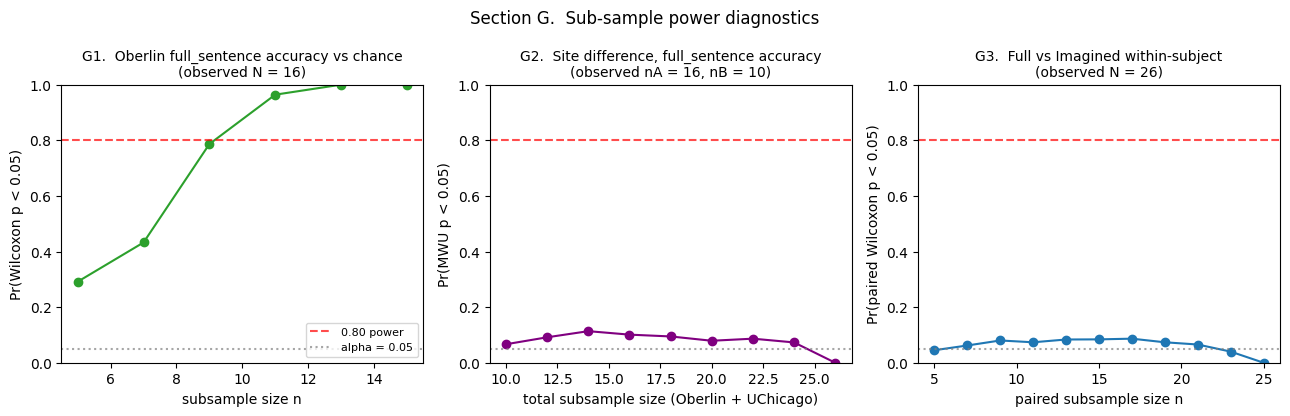

In [69]:
# ============================================================================
# Section G -- combined power-curve figure
# ============================================================================

fig, axes_row = plt.subplots(1, 3, figsize = (13, 4.2))

ax = axes_row[0]
ax.plot(g1_power_table["n_sub"], g1_power_table["power"], marker = "o",
         color = SITE_COLOR["Oberlin"])
ax.axhline(0.80, color = "red",  linestyle = "--", alpha = 0.7,
            label = "0.80 power")
ax.axhline(0.05, color = "gray", linestyle = ":",  alpha = 0.7,
            label = "alpha = 0.05")
ax.set_xlabel("subsample size n")
ax.set_ylabel("Pr(Wilcoxon p < 0.05)")
ax.set_title("G1.  Oberlin full_sentence accuracy vs chance\n"
              f"(observed N = {len(oberlin_full_sentence_accuracies)})",
              fontsize = 10)
ax.legend(loc = "lower right", fontsize = 8); ax.set_ylim(0, 1)

ax = axes_row[1]
ax.plot(g2_power_table["n_total"], g2_power_table["power"], marker = "o",
         color = "purple")
ax.axhline(0.80, color = "red",  linestyle = "--", alpha = 0.7)
ax.axhline(0.05, color = "gray", linestyle = ":",  alpha = 0.7)
ax.set_xlabel("total subsample size (Oberlin + UChicago)")
ax.set_ylabel("Pr(MWU p < 0.05)")
ax.set_title("G2.  Site difference, full_sentence accuracy\n"
              f"(observed nA = {len(accuracy_oberlin_full)}, "
              f"nB = {len(accuracy_uchicago_full)})", fontsize = 10)
ax.set_ylim(0, 1)

ax = axes_row[2]
ax.plot(g3_power_table["n_sub"], g3_power_table["power"], marker = "o",
         color = SITE_COLOR["Unified"])
ax.axhline(0.80, color = "red",  linestyle = "--", alpha = 0.7)
ax.axhline(0.05, color = "gray", linestyle = ":",  alpha = 0.7)
ax.set_xlabel("paired subsample size n")
ax.set_ylabel("Pr(paired Wilcoxon p < 0.05)")
ax.set_title("G3.  Full vs Imagined within-subject\n"
              f"(observed N = {len(unified_full_minus_imagined)})",
              fontsize = 10)
ax.set_ylim(0, 1)

plt.suptitle("Section G.  Sub-sample power diagnostics", fontsize = 12)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "G_power_curves.png", dpi = 140)
plt.show()


In [71]:
# ============================================================================
# Section G -- empirical "N for 80% power" summary table
# ============================================================================

def n_for_target_power(power_table, n_column = "n_sub", target_power = 0.80):
    above_target = power_table[power_table["power"] >= target_power]
    if len(above_target) == 0:
        return None
    return int(above_target.iloc[0][n_column])


required_n_rows = [
    dict(comparison        = "Oberlin full_sentence vs chance",
         observed_n        = len(oberlin_full_sentence_accuracies),
         observed_p        = float(accuracy_vs_chance_table.query(
             "block == 'full_sentence' and group == 'Oberlin'"
         ).iloc[0]["wilcoxon_p"]),
         observed_d        = float(accuracy_vs_chance_table.query(
             "block == 'full_sentence' and group == 'Oberlin'"
         ).iloc[0]["cohens_d"]),
         n_for_80pct_power = n_for_target_power(g1_power_table, "n_sub")),
    dict(comparison        = "Site Oberlin vs UChicago, full_sentence",
         observed_n        = (len(accuracy_oberlin_full)
                               + len(accuracy_uchicago_full)),
         observed_p        = float(site_comparison_table.query(
             "block == 'full_sentence'").iloc[0]["mwu_p"]),
         observed_d        = float(site_comparison_table.query(
             "block == 'full_sentence'").iloc[0]["cohens_d"]),
         n_for_80pct_power = n_for_target_power(g2_power_table, "n_total")),
    dict(comparison        = "Full vs Imagined paired (Unified)",
         observed_n        = len(unified_full_minus_imagined),
         observed_p        = float(full_vs_imagined_table.query(
             "group == 'Unified'").iloc[0]["wilcoxon_p"]),
         observed_d        = float(full_vs_imagined_table.query(
             "group == 'Unified'").iloc[0]["cohens_d_paired"]),
         n_for_80pct_power = n_for_target_power(g3_power_table, "n_sub"))]

required_n_table = pd.DataFrame(required_n_rows)
required_n_table.to_csv(TABLES_PATH / "G_required_n_summary.csv",
                         index = False)

print("\n--- N required for 80% power ---")
print(required_n_table.to_string(index = False))



--- N required for 80% power ---
                             comparison  observed_n  observed_p  observed_d  n_for_80pct_power
        Oberlin full_sentence vs chance          16    0.003679    0.985842               11.0
Site Oberlin vs UChicago, full_sentence          26    0.145292    0.649263                NaN
      Full vs Imagined paired (Unified)          26    0.157151    0.289586                NaN


In [72]:
# ============================================================================
# Section H -- additional sub-sample power: one-sample vs chance
#   H1a. UChicago full_sentence  vs chance
#   H1b. Oberlin  imagined       vs chance
#   H1c. UChicago imagined       vs chance
#   H1d. Unified  imagined       vs chance
# ============================================================================

print("\n=== Section H: extra one-sample power vs chance ===")

# Pull each per-subject accuracy vector
accuracy_uchicago_full      = per_subject_table.query(
    "site == 'UChicago' and block_type == 'full_sentence'")["accuracy"].values
accuracy_oberlin_imagined   = per_subject_table.query(
    "site == 'Oberlin'  and block_type == 'imagined_sentence'")["accuracy"].values
accuracy_uchicago_imagined  = per_subject_table.query(
    "site == 'UChicago' and block_type == 'imagined_sentence'")["accuracy"].values
accuracy_unified_imagined   = per_subject_table.query(
    "block_type == 'imagined_sentence'")["accuracy"].values

# Run sub-sample power for each
h1a_power_table = subsample_power_one_sample(accuracy_uchicago_full,     null_mean = 0.5)
h1b_power_table = subsample_power_one_sample(accuracy_oberlin_imagined,  null_mean = 0.5)
h1c_power_table = subsample_power_one_sample(accuracy_uchicago_imagined, null_mean = 0.5)
h1d_power_table = subsample_power_one_sample(accuracy_unified_imagined,  null_mean = 0.5)

# Save
h1a_power_table.to_csv(TABLES_PATH / "H_power_uchicago_fs_vs_chance.csv",       index = False)
h1b_power_table.to_csv(TABLES_PATH / "H_power_oberlin_imagined_vs_chance.csv",  index = False)
h1c_power_table.to_csv(TABLES_PATH / "H_power_uchicago_imagined_vs_chance.csv", index = False)
h1d_power_table.to_csv(TABLES_PATH / "H_power_unified_imagined_vs_chance.csv",  index = False)

print("h1a head:\n", h1a_power_table.head().round(3).to_string(index = False))
print("h1d head:\n", h1d_power_table.head().round(3).to_string(index = False))


=== Section H: extra one-sample power vs chance ===
h1a head:
  n_sub  power  mean_of_means  sd_of_means
     5  0.006          0.504        0.013
     7  0.000          0.504        0.009
     9  0.000          0.504        0.005
h1d head:
  n_sub  power  mean_of_means  sd_of_means
     5  0.050          0.502        0.015
     7  0.038          0.502        0.012
     9  0.024          0.502        0.010
    11  0.027          0.502        0.009
    13  0.030          0.503        0.007


In [73]:
# ============================================================================
# Section H -- additional sub-sample power: between- and within-site contrasts
#   H2a. Site difference, imagined_sentence (unpaired MWU)
#   H2b. Full vs Imagined paired, Oberlin only
#   H2c. Full vs Imagined paired, UChicago only
# ============================================================================

print("\n=== Section H: extra site / paired power ===")

# H2a: site diff, imagined block
h2a_power_table = subsample_power_two_sample(accuracy_oberlin_imagined,
                                              accuracy_uchicago_imagined)
h2a_power_table.to_csv(TABLES_PATH / "H_power_site_imagined_sentence.csv",
                        index = False)

# H2b/c: paired full - imagined within each site
def paired_diffs_for_site(site_name):
    wide = (per_subject_table.query("site == @site_name")
            .pivot(index = "subject", columns = "block_type",
                   values = "accuracy").dropna())
    return (wide["full_sentence"] - wide["imagined_sentence"]).values

oberlin_full_minus_imagined  = paired_diffs_for_site("Oberlin")
uchicago_full_minus_imagined = paired_diffs_for_site("UChicago")

h2b_power_table = subsample_power_paired(oberlin_full_minus_imagined)
h2c_power_table = subsample_power_paired(uchicago_full_minus_imagined)

h2b_power_table.to_csv(TABLES_PATH / "H_power_full_vs_imagined_oberlin.csv",
                        index = False)
h2c_power_table.to_csv(TABLES_PATH / "H_power_full_vs_imagined_uchicago.csv",
                        index = False)

print("h2a head:\n", h2a_power_table.head().round(3).to_string(index = False))
print("h2b head:\n", h2b_power_table.head().round(3).to_string(index = False))
print("h2c head:\n", h2c_power_table.head().round(3).to_string(index = False))


=== Section H: extra site / paired power ===
h2a head:
  n_total  n_a  n_b  power  mean_diff  sd_diff
      10    6    4  0.022       0.02    0.020
      12    7    5  0.014       0.02    0.016
      14    9    5  0.022       0.02    0.016
      16   10    6  0.016       0.02    0.013
      18   11    7  0.000       0.02    0.010
h2b head:
  n_sub  power  mean_diff
     5  0.032      0.016
     7  0.063      0.017
     9  0.054      0.016
    11  0.056      0.016
    13  0.037      0.016
h2c head:
  n_sub  power  mean_diff
     5  0.032      0.014
     7  0.020      0.014
     9  0.000      0.014


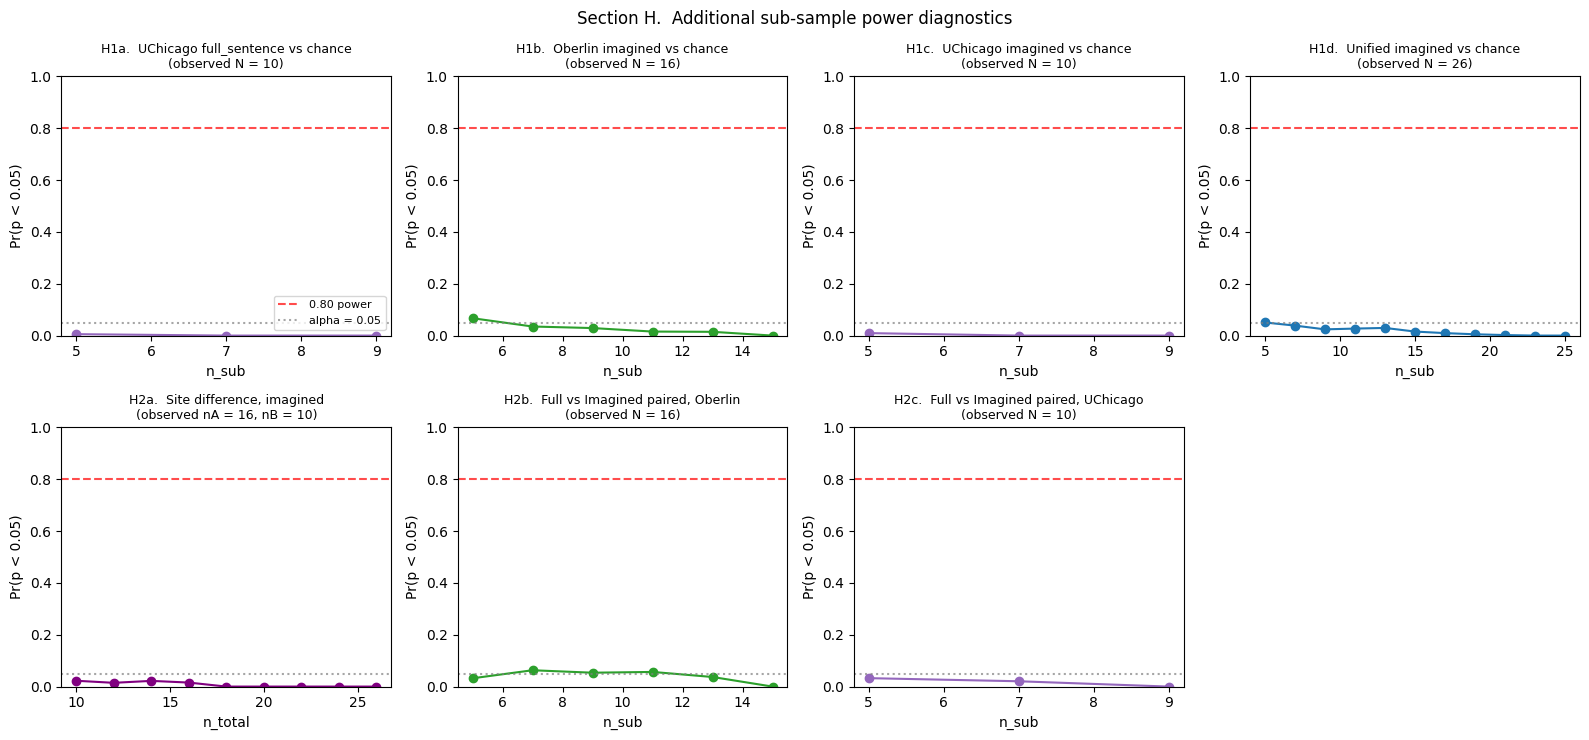

In [74]:
# ============================================================================
# Section H -- combined power-curve figure for the seven extra tests
# ============================================================================

# Each entry: (power_table, x-column, color, panel title)
H_PANELS = [
    (h1a_power_table, "n_sub",   SITE_COLOR["UChicago"],
     "H1a.  UChicago full_sentence vs chance\n"
     f"(observed N = {len(accuracy_uchicago_full)})"),
    (h1b_power_table, "n_sub",   SITE_COLOR["Oberlin"],
     "H1b.  Oberlin imagined vs chance\n"
     f"(observed N = {len(accuracy_oberlin_imagined)})"),
    (h1c_power_table, "n_sub",   SITE_COLOR["UChicago"],
     "H1c.  UChicago imagined vs chance\n"
     f"(observed N = {len(accuracy_uchicago_imagined)})"),
    (h1d_power_table, "n_sub",   SITE_COLOR["Unified"],
     "H1d.  Unified imagined vs chance\n"
     f"(observed N = {len(accuracy_unified_imagined)})"),
    (h2a_power_table, "n_total", "purple",
     "H2a.  Site difference, imagined\n"
     f"(observed nA = {len(accuracy_oberlin_imagined)}, "
     f"nB = {len(accuracy_uchicago_imagined)})"),
    (h2b_power_table, "n_sub",   SITE_COLOR["Oberlin"],
     "H2b.  Full vs Imagined paired, Oberlin\n"
     f"(observed N = {len(oberlin_full_minus_imagined)})"),
    (h2c_power_table, "n_sub",   SITE_COLOR["UChicago"],
     "H2c.  Full vs Imagined paired, UChicago\n"
     f"(observed N = {len(uchicago_full_minus_imagined)})"),
]

# 2 rows x 4 columns; final cell stays empty
fig, axes_grid = plt.subplots(2, 4, figsize = (16, 7.5))
axes_flat = axes_grid.flatten()

# Plot each panel
for panel_index, (power_table, x_column, color, title) in enumerate(H_PANELS):
    ax = axes_flat[panel_index]
    ax.plot(power_table[x_column], power_table["power"], marker = "o",
             color = color)
    # Reference lines: 0.80 power target and alpha = 0.05
    ax.axhline(0.80, color = "red",  linestyle = "--", alpha = 0.7,
                label = "0.80 power")
    ax.axhline(0.05, color = "gray", linestyle = ":",  alpha = 0.7,
                label = "alpha = 0.05")
    ax.set_xlabel(x_column)
    ax.set_ylabel("Pr(p < 0.05)")
    ax.set_title(title, fontsize = 9)
    ax.set_ylim(0, 1)
    if panel_index == 0:
        ax.legend(loc = "lower right", fontsize = 8)

# Hide the empty 8th panel
axes_flat[-1].axis("off")

# Add the overall graph title, save and show
plt.suptitle("Section H.  Additional sub-sample power diagnostics", fontsize = 12)
plt.tight_layout()
plt.savefig(FIGURES_PATH / "H_power_curves_extra.png", dpi = 140)
plt.show()

In [75]:
# ============================================================================
# Section H -- empirical "N for 80% power" summary table for the extras
# ============================================================================

# One row per extra comparison.  Reuses n_for_target_power() defined in Section G.
extra_required_n_rows = [
    dict(comparison        = "UChicago full_sentence vs chance",
         observed_n        = len(accuracy_uchicago_full),
         n_for_80pct_power = n_for_target_power(h1a_power_table, "n_sub")),
    dict(comparison        = "Oberlin imagined vs chance",
         observed_n        = len(accuracy_oberlin_imagined),
         n_for_80pct_power = n_for_target_power(h1b_power_table, "n_sub")),
    dict(comparison        = "UChicago imagined vs chance",
         observed_n        = len(accuracy_uchicago_imagined),
         n_for_80pct_power = n_for_target_power(h1c_power_table, "n_sub")),
    dict(comparison        = "Unified imagined vs chance",
         observed_n        = len(accuracy_unified_imagined),
         n_for_80pct_power = n_for_target_power(h1d_power_table, "n_sub")),
    dict(comparison        = "Site Oberlin vs UChicago, imagined",
         observed_n        = (len(accuracy_oberlin_imagined)
                               + len(accuracy_uchicago_imagined)),
         n_for_80pct_power = n_for_target_power(h2a_power_table, "n_total")),
    dict(comparison        = "Full vs Imagined paired, Oberlin",
         observed_n        = len(oberlin_full_minus_imagined),
         n_for_80pct_power = n_for_target_power(h2b_power_table, "n_sub")),
    dict(comparison        = "Full vs Imagined paired, UChicago",
         observed_n        = len(uchicago_full_minus_imagined),
         n_for_80pct_power = n_for_target_power(h2c_power_table, "n_sub")),
]

extra_required_n_table = pd.DataFrame(extra_required_n_rows)
extra_required_n_table.to_csv(TABLES_PATH / "H_required_n_summary_extra.csv",
                                index = False)

print("\n--- N required for 80% power (extras) ---")
print(extra_required_n_table.to_string(index = False))


--- N required for 80% power (extras) ---
                        comparison  observed_n n_for_80pct_power
  UChicago full_sentence vs chance          10              None
        Oberlin imagined vs chance          16              None
       UChicago imagined vs chance          10              None
        Unified imagined vs chance          26              None
Site Oberlin vs UChicago, imagined          26              None
  Full vs Imagined paired, Oberlin          16              None
 Full vs Imagined paired, UChicago          10              None


In [76]:
print(f"\nDone.  Tables -> {TABLES_PATH}")
print(f"        Figures -> {FIGURES_PATH}")



Done.  Tables -> /home/david/Desktop/Projects/auditory-sp-analyses/jupyter_notebook/tables
        Figures -> /home/david/Desktop/Projects/auditory-sp-analyses/jupyter_notebook/figures
